In [ ]:
# =============================================================================
# NATURAL GAS STORAGE ANALYSIS by Mehrdad Heyrani
# Part 1: Seasonal Year-over-Year Storage Overlay (per region + total)
# Part 2: Analyst-Style Forward Forecast Fan from Last Actual
#           Models: SARIMA · Fourier-ARIMAX · Holt-Winters · Degree-Day OLS
# Literature: EIA STEO methodology
# Data: EIA Weekly Underground Storage from EIA
# =============================================================================


In [1]:
from google.colab import files

print("Please upload the 'gas_realized.xlsx' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f"User uploaded file '{fn}' with length {len(uploaded[fn])} bytes")


Please upload the 'gas_realized.xlsx' file:


Saving gas_realized.xlsx to gas_realized.xlsx
User uploaded file 'gas_realized.xlsx' with length 1502741 bytes


In [2]:
!pip install arch pyvinecopulib openpyxl statsmodels scipy pandas numpy \
             matplotlib seaborn scikit-learn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.6 MB/s eta 0:00:00


In [3]:
!pip install prophet statsmodels arch scikit-learn openpyxl pandas numpy matplotlib seaborn scipy tqdm -q

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
#  IMPORTS & SETTINGS
# ╚══════════════════════════════════════════════════════════════════════════════

import warnings; warnings.filterwarnings("ignore")
import os, math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib import cm
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy.signal import periodogram
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

plt.rcParams.update({
    "figure.dpi": 150, "font.family": "DejaVu Sans",
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.fontsize": 8, "figure.facecolor": "white",
})

DATA_PATH  = "gas_realized.xlsx"
OUT_FOLDER = "/content/"
os.makedirs(OUT_FOLDER, exist_ok=True)

REGIONS = ["East", "Midwest", "Mountain", "Pacific", "SouthCentral", "Total"]

# ── Year colour palette (one colour per calendar year, 2010–2026) ─────────────
# 2026 = bold black (current year), 2025 = red, older = graduated palette
def year_color_palette(years, current_year):
    cmap   = plt.cm.tab20
    colors = {}
    historic = [y for y in years if y < current_year - 1]
    for i, y in enumerate(historic):
        colors[y] = cmap(i / max(len(historic) - 1, 1))
    colors[current_year - 1] = "#CC0000"   # last full year = red (like chart 1)
    colors[current_year]     = "black"     # current year = black bold
    return colors

print("✓ Imports complete")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
#  DATA LOADING
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Loading Data ──")

# Storage
stor_raw = pd.read_excel(DATA_PATH, sheet_name="storage Data", skiprows=6)
stor_raw.columns = ["Week","Source","East","Midwest","Mountain","Pacific",
                    "SouthCentral","Salt","NonSalt","Total"]
stor = (stor_raw
        .assign(Week=lambda d: pd.to_datetime(d["Week"]))
        .dropna(subset=["Total","Week"])
        .sort_values("Week")
        .reset_index(drop=True))

# Prices
prices_raw = pd.read_excel(DATA_PATH, sheet_name="NGI_GAS")
prices_raw.columns = ["Date","Algonquin","Chicago_CG","Dom_North",
                      "Dom_South","Henry_Hub","Waha"]
prices_raw["Date"] = pd.to_datetime(prices_raw["Date"])
prices_raw = prices_raw.dropna(subset=["Henry_Hub"])
prices_raw["Week"] = (
    prices_raw["Date"]
    + pd.to_timedelta((4 - prices_raw["Date"].dt.dayofweek) % 7, unit="D")
)
prices_weekly = (prices_raw.groupby("Week")
    .agg(HH_avg=("Henry_Hub","mean"), HH_vol=("Henry_Hub","std"))
    .reset_index())
prices_weekly["Week"] = pd.to_datetime(prices_weekly["Week"])

# Merge
stor = stor.sort_values("Week").reset_index(drop=True)
prices_weekly = prices_weekly.sort_values("Week").reset_index(drop=True)
stor = pd.merge_asof(stor, prices_weekly, on="Week",
                     direction="nearest", tolerance=pd.Timedelta("4D"))

stor["Year"]      = stor["Week"].dt.year
stor["Month"]     = stor["Week"].dt.month
stor["WeekOfYear"]= stor["Week"].dt.isocalendar().week.astype(int)
stor["DayOfYear"] = stor["Week"].dt.dayofyear

CURRENT_YEAR = stor["Week"].max().year
ALL_YEARS    = sorted(stor["Year"].unique())
COLORS       = year_color_palette(ALL_YEARS, CURRENT_YEAR)

print(f"  Storage : {len(stor):,} weekly obs  "
      f"{stor['Week'].min().date()} → {stor['Week'].max().date()}")
print(f"  Years   : {ALL_YEARS[0]} – {ALL_YEARS[-1]}")
print(f"  Current year: {CURRENT_YEAR}  "
      f"(last obs: {stor['Week'].max().date()})")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
# SEASONAL OVERLAY FRAMEWORK
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Building Seasonal Overlay Data ──")

def build_seasonal_df(df, region):
    """
    Reshape storage data so each year becomes a column,
    indexed by week-of-year (1-52).  Missing weeks = NaN.
    """
    pivot = (df[["Year","WeekOfYear", region]]
             .dropna(subset=[region])
             .pivot_table(index="WeekOfYear", columns="Year",
                          values=region, aggfunc="mean"))
    return pivot

# 5-year rolling average (using last 5 full years before current)
def compute_5yr_avg(pivot, current_year, n=5):
    full_years = [y for y in pivot.columns
                  if y < current_year and pivot[y].notna().sum() > 40]
    recent_n   = sorted(full_years)[-n:]
    avg  = pivot[recent_n].mean(axis=1)
    std  = pivot[recent_n].std(axis=1)
    return avg, std, recent_n

# Week-of-year → representative date using 2023 as anchor year
def woy_to_date(woy_series, anchor_year=2024):
    """Convert week-of-year integers to approximate calendar dates."""
    base = pd.Timestamp(f"{anchor_year}-01-01")
    return [base + pd.Timedelta(weeks=int(w)-1) for w in woy_series]

for reg in REGIONS:
    pivot = build_seasonal_df(stor, reg)
    avg5, std5, used_years = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)
    print(f"  {reg:<16} 5yr avg uses: {used_years}")

print("  Seasonal overlay ready ✓")

# ╔══════════════════════════════════════════════════════════════════════════════
#  CHART 1: SEASONAL OVERLAY
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Chart 1: Seasonal Year-over-Year Overlay ──")

def plot_seasonal_overlay(region, show_5yr_band=True,
                          highlight_years=None, figsize=(14, 6)):
    pivot   = build_seasonal_df(stor, region)
    avg5, std5, used_yrs = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)
    x_dates = woy_to_date(pivot.index)

    fig, ax = plt.subplots(figsize=figsize)

    # ── 5-year average band ────────────────────────────────────────────────
    if show_5yr_band:
        ax.fill_between(x_dates, avg5 - std5, avg5 + std5,
                        color="grey", alpha=0.15, zorder=1,
                        label=f"5YrAvg ±1SD ({used_yrs[0]}–{used_yrs[-1]})")
        ax.plot(x_dates, avg5.values, color="grey", linewidth=1.8,
                linestyle="--", zorder=2, label="5-Year Average")

    # ── Historical years (thin, semi-transparent) ──────────────────────────
    legend_entries = []
    plot_years = sorted(pivot.columns)

    for yr in plot_years:
        col  = pivot[yr].dropna()
        if len(col) < 4:
            continue
        xd   = woy_to_date(col.index)
        clr  = COLORS.get(yr, "lightgrey")
        lw   = 2.5 if yr == CURRENT_YEAR else (2.0 if yr == CURRENT_YEAR-1 else 1.0)
        alph = 1.0 if yr >= CURRENT_YEAR-1 else 0.65
        zo   = 5 if yr == CURRENT_YEAR else (4 if yr == CURRENT_YEAR-1 else 2)
        ax.plot(xd, col.values, color=clr, linewidth=lw, alpha=alph,
                zorder=zo)
        legend_entries.append(Line2D([0],[0], color=clr, linewidth=lw,
                                     label=str(yr)))

    # ── Axis formatting — match reference chart style ──────────────────────
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=4, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=60, ha="right",
             fontsize=7)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.set_ylabel("Bcf", fontsize=9)
    ax.set_title(f"{region} Storage  (BCF)", fontsize=12, fontweight="bold",
                 pad=10)
    ax.set_xlim(x_dates[0], x_dates[-1])
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.grid(axis="x", alpha=0.15, linewidth=0.4)

    # Legend — outside bottom, matching reference chart layout
    if show_5yr_band:
        legend_entries = (
            [Line2D([0],[0], color="grey", linewidth=1.8,
                    linestyle="--", label="5-Year Average")] +
            legend_entries
        )
    ax.legend(handles=legend_entries, loc="upper center",
              bbox_to_anchor=(0.5, -0.22), ncol=len(plot_years)+1,
              frameon=True, fontsize=7.5,
              handler_map={Line2D: matplotlib.legend_handler.HandlerLine2D()})

    plt.tight_layout()
    fname = os.path.join(OUT_FOLDER, f"Chart1_{region}_seasonal_overlay.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"  Saved: {fname}")
    return fname

# Generate for all regions
for reg in REGIONS:
    plot_seasonal_overlay(reg)

# ╔══════════════════════════════════════════════════════════════════════════════
#  COMBINED OVERLAY  (all 5 regions on one 2×3 grid)
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Chart 1b: Combined 6-Region Overlay ──")

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

for ax, reg in zip(axes, REGIONS):
    pivot   = build_seasonal_df(stor, reg)
    avg5, std5, used_yrs = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)
    x_dates = woy_to_date(pivot.index)

    # 5yr band
    ax.fill_between(x_dates, (avg5-std5).values, (avg5+std5).values,
                    color="grey", alpha=0.12, zorder=1)
    ax.plot(x_dates, avg5.values, color="grey", linewidth=1.5,
            linestyle="--", zorder=2)

    legend_handles = []
    for yr in sorted(pivot.columns):
        col = pivot[yr].dropna()
        if len(col) < 4: continue
        xd  = woy_to_date(col.index)
        clr = COLORS.get(yr, "lightgrey")
        lw  = 2.8 if yr == CURRENT_YEAR else (2.0 if yr == CURRENT_YEAR-1 else 0.9)
        alph= 1.0 if yr >= CURRENT_YEAR-1 else 0.6
        zo  = 5 if yr == CURRENT_YEAR else (4 if yr == CURRENT_YEAR-1 else 2)
        ax.plot(xd, col.values, color=clr, linewidth=lw,
                alpha=alph, zorder=zo)
        legend_handles.append(
            Line2D([0],[0], color=clr, linewidth=max(lw,1.0),
                   label=str(yr)))

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right",
             fontsize=7)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.set_title(f"{reg} Storage (BCF)", fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.25, linewidth=0.5)
    ax.set_xlim(x_dates[0], x_dates[-1])

# Shared legend below all subplots
all_handles = (
    [Line2D([0],[0], color="grey", linewidth=1.5, linestyle="--",
             label="5-Year Avg")] +
    [Line2D([0],[0], color=COLORS.get(y,"grey"), linewidth=1.2,
             label=str(y)) for y in sorted(ALL_YEARS) if y in COLORS]
)
fig.legend(handles=all_handles, loc="lower center",
           bbox_to_anchor=(0.5, -0.03), ncol=len(ALL_YEARS)+1,
           frameon=True, fontsize=8)
fig.suptitle("EIA Weekly Natural Gas Storage — Year-over-Year Seasonal Overlay",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fname_combined = os.path.join(OUT_FOLDER, "Chart1_all_regions_combined.png")
fig.savefig(fname_combined, dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"  Saved: {fname_combined}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
#  FORECAST MODELS  (fitted up to last actual date)
#  · SARIMA(1,1,1)(1,1,1)[]
#  · Fourier-ARIMAX
#  · Holt-Winters ETS
#  · Degree-Day OLS regression
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Fitting Forecast Models ──")

FORECAST_WEEKS = 16   # how many weeks forward to project in Chart 2

def to_arr(x):
    """Convert Series/array/scalar to clean numpy float array."""
    if hasattr(x, "values"): return np.asarray(x.values, dtype=float)
    return np.asarray(x, dtype=float)

def safe_ci(fcast_obj, alpha):
    ci = fcast_obj.conf_int(alpha=alpha)
    ci = np.asarray(ci, dtype=float)
    if ci.ndim == 1: ci = ci.reshape(-1, 2)
    return ci[:,0], ci[:,1]

def fourier_terms(n, period, K):
    """K pairs of sin/cos Fourier terms for given period."""
    t = np.arange(n)
    cols = {}
    for k in range(1, K+1):
        cols[f"sin_{k}"] = np.sin(2*np.pi*k*t/period)
        cols[f"cos_{k}"] = np.cos(2*np.pi*k*t/period)
    return pd.DataFrame(cols)

# ── For each region, fit 4 models on the full history ─────────────────────────
model_forecasts = {}   # region → {model_name → array of length FORECAST_WEEKS}
model_colors    = {
    "SARIMA":        "#1f77b4",   # blue
    "Fourier-ARIMAX":"#2ca02c",   # green
    "Holt-Winters":  "#9467bd",   # purple
    "Degree-Day OLS":"#d62728",   # red
    "Ensemble":      "#ff7f0e",   # orange
}

for reg in REGIONS:
    ts = stor[reg].dropna().values
    n  = len(ts)
    print(f"\n  {reg} (n={n})")
    model_forecasts[reg] = {}

    # ── Model 1: SARIMA(1,1,1)(1,1,1)[52] ─────────────────────────────────
    try:
        m1 = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,52),
                     enforce_stationarity=False, enforce_invertibility=False)
        r1 = m1.fit(disp=False, maxiter=200, method="lbfgs")
        f1 = r1.get_forecast(FORECAST_WEEKS)
        model_forecasts[reg]["SARIMA"] = to_arr(f1.predicted_mean)
        # Store CI for SARIMA (used as reference band in Chart 2)
        lo95, hi95 = safe_ci(f1, alpha=0.05)
        model_forecasts[reg]["SARIMA_lo95"] = lo95
        model_forecasts[reg]["SARIMA_hi95"] = hi95
        lo80, hi80 = safe_ci(f1, alpha=0.20)
        model_forecasts[reg]["SARIMA_lo80"] = lo80
        model_forecasts[reg]["SARIMA_hi80"] = hi80
        print(f"    SARIMA         AIC={r1.aic:.1f} ✓")
    except Exception as e:
        print(f"    SARIMA         FAILED: {e}")

    # ── Model 2: Fourier-ARIMAX (K=6 harmonics, seasonal period=52) ───────
    try:
        K = 6
        n_total = n + FORECAST_WEEKS
        FF_all  = fourier_terms(n_total, period=52, K=K)
        X_train = FF_all.iloc[:n].values
        X_fcast = FF_all.iloc[n:].values
        m2 = SARIMAX(ts, exog=X_train, order=(1,1,1),
                     enforce_stationarity=False, enforce_invertibility=False)
        r2 = m2.fit(disp=False, maxiter=200, method="lbfgs")
        f2 = r2.get_forecast(FORECAST_WEEKS, exog=X_fcast)
        model_forecasts[reg]["Fourier-ARIMAX"] = to_arr(f2.predicted_mean)
        print(f"    Fourier-ARIMAX AIC={r2.aic:.1f} ✓")
    except Exception as e:
        print(f"    Fourier-ARIMAX FAILED: {e}")

    # ── Model 3: Holt-Winters ETS ─────────────────────────────────────────
    try:
        import warnings as _w
        with _w.catch_warnings():
            _w.simplefilter("ignore")
            m3 = ExponentialSmoothing(ts, trend="add", seasonal="add",
                                      seasonal_periods=52,
                                      initialization_method="estimated")
            r3 = m3.fit(optimized=True, remove_bias=True,
                        minimizer_kwargs={"method":"L-BFGS-B",
                                          "options":{"maxiter":500}})
        model_forecasts[reg]["Holt-Winters"] = to_arr(r3.forecast(FORECAST_WEEKS))
        print(f"    Holt-Winters   AIC={r3.aic:.1f} ✓")
    except Exception as e:
        print(f"    Holt-Winters   FAILED: {e}")

    # ── Model 4: Degree-Day OLS  ───────────────────────────────────────────
    # Literature: EIA STEO supplemental model
    # Storage_wk = β0 + β1·Storage_{wk-1} + β2·HDD + β3·CDD +
    #              β4·sin(2π·woy/52) + β5·cos(2π·woy/52) + ε
    # When HDD/CDD not available (our dataset), use synthetic weather signal:
    # synthetic_HDD = max(0, 65 - T_normal) where T_normal is the 30-yr
    # climatological temperature for that week (approximated via sine curve)
    try:
        df_ols = stor[["Week","WeekOfYear","HH_avg",reg]].dropna(
            subset=[reg]).copy()
        df_ols["lag1"]    = df_ols[reg].shift(1)
        df_ols["woy_sin"] = np.sin(2*np.pi*df_ols["WeekOfYear"]/52)
        df_ols["woy_cos"] = np.cos(2*np.pi*df_ols["WeekOfYear"]/52)
        df_ols["woy_sin2"]= np.sin(4*np.pi*df_ols["WeekOfYear"]/52)
        df_ols["woy_cos2"]= np.cos(4*np.pi*df_ols["WeekOfYear"]/52)
        # Synthetic degree-day proxy from seasonal temperature cycle
        T_synth = 55 + 20*np.sin(2*np.pi*(df_ols["WeekOfYear"]-13)/52)
        df_ols["HDD_synth"] = np.maximum(0, 65 - T_synth)
        df_ols["CDD_synth"] = np.maximum(0, T_synth - 65)
        # Use HH price as demand-side proxy where available
        hh_mean = df_ols["HH_avg"].mean(skipna=True)
        df_ols["HH_fill"] = df_ols["HH_avg"].fillna(hh_mean)
        df_ols = df_ols.dropna(subset=["lag1"])

        X_ols = sm.add_constant(df_ols[["lag1","woy_sin","woy_cos",
                                         "woy_sin2","woy_cos2",
                                         "HDD_synth","CDD_synth","HH_fill"]])
        y_ols = df_ols[reg]
        lm    = sm.OLS(y_ols, X_ols.astype(float)).fit()

        # Recursive 16-step forecast
        ols_fcast = []
        last_obs  = float(stor[reg].dropna().iloc[-1])
        last_woy  = int(stor["WeekOfYear"].iloc[-1])
        last_hh   = (stor["HH_avg"].dropna().iloc[-1]
                     if stor["HH_avg"].notna().any() else hh_mean)
        cur_val   = last_obs
        for h in range(1, FORECAST_WEEKS+1):
            woy_h = ((last_woy + h - 1) % 52) + 1
            T_h   = 55 + 20*np.sin(2*np.pi*(woy_h-13)/52)
            hdd_h = max(0, 65 - T_h)
            cdd_h = max(0, T_h - 65)
            X_h   = np.array([1, cur_val,
                               np.sin(2*np.pi*woy_h/52),
                               np.cos(2*np.pi*woy_h/52),
                               np.sin(4*np.pi*woy_h/52),
                               np.cos(4*np.pi*woy_h/52),
                               hdd_h, cdd_h, last_hh])
            pred  = float(lm.params @ X_h)
            ols_fcast.append(pred)
            cur_val = pred

        model_forecasts[reg]["Degree-Day OLS"] = np.array(ols_fcast)
        print(f"    Degree-Day OLS R²={lm.rsquared:.4f} ✓")
    except Exception as e:
        print(f"    Degree-Day OLS FAILED: {e}")

    # ── Ensemble: mean of available model forecasts ────────────────────────
    avail = [v for k,v in model_forecasts[reg].items()
             if k in model_colors and k != "Ensemble"]
    if avail:
        ens_mat = np.column_stack(avail)
        model_forecasts[reg]["Ensemble"] = np.nanmean(ens_mat, axis=1)
        print(f"    Ensemble       ({len(avail)} models)")

In [ ]:

print("\n── Chart 2: Analyst-Style Forecast Fan ──")

def plot_forecast_fan(region, history_weeks=24, figsize=(14, 7)):
    """
    Replicates the analyst forecast chart style:
    - Historical window + forward fan
    - 5-year average as dashed line
    - Last year as black solid
    - Each model forecast as a distinct coloured line
    - Shaded 80% / 95% CI from SARIMA
    - Vertical line at forecast start
    """
    reg_ts   = stor[["Week","WeekOfYear","Year",region]].dropna(subset=[region])
    last_date= reg_ts["Week"].max()
    last_val = float(reg_ts[region].iloc[-1])

    # Future dates
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=7),
        periods=FORECAST_WEEKS, freq="7D"
    )

    # 5-year average on same WoY horizon
    pivot = build_seasonal_df(stor, region)
    avg5, std5, _ = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)

    # Map future WoY to 5yr avg values
    future_woys   = [(last_date + pd.Timedelta(weeks=h)).isocalendar()[1]
                     for h in range(1, FORECAST_WEEKS+1)]
    avg5_future   = np.array([avg5.get(w, np.nan) for w in future_woys])

    # Historical tail (last `history_weeks` actuals)
    hist_tail = reg_ts.tail(history_weeks + 1)

    # Last-year actuals for the same calendar window
    prev_year    = CURRENT_YEAR - 1
    prev_yr_data = stor[stor["Year"] == prev_year][["Week","WeekOfYear",region]]
    prev_yr_data = prev_yr_data.copy()
    # Shift last-year dates forward by 1 year for alignment
    prev_yr_data["Week_shifted"] = prev_yr_data["Week"] + pd.DateOffset(years=1)

    # 5yr avg full (history + forecast window aligned)
    hist_woys   = hist_tail["WeekOfYear"].values
    avg5_hist   = np.array([avg5.get(int(w), np.nan) for w in hist_woys])
    hist_dates  = pd.date_range(
        start=last_date - pd.Timedelta(weeks=history_weeks),
        periods=history_weeks+1, freq="7D"
    )

    # ── Figure ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # SARIMA confidence bands (shaded)
    if "SARIMA_lo95" in model_forecasts.get(region, {}):
        mf = model_forecasts[region]
        ax.fill_between(future_dates,
                        mf["SARIMA_lo95"], mf["SARIMA_hi95"],
                        color="#1f77b4", alpha=0.08, zorder=1,
                        label="SARIMA 95% PI")
        ax.fill_between(future_dates,
                        mf["SARIMA_lo80"], mf["SARIMA_hi80"],
                        color="#1f77b4", alpha=0.15, zorder=2,
                        label="SARIMA 80% PI")

    # 5-year average dashed (history + forecast)
    all_5yr_dates = list(hist_dates) + list(future_dates)
    all_5yr_vals  = np.concatenate([avg5_hist, avg5_future])
    valid_mask    = np.isfinite(all_5yr_vals)
    if valid_mask.any():
        ax.plot(np.array(all_5yr_dates)[valid_mask],
                all_5yr_vals[valid_mask],
                color="black", linewidth=1.8, linestyle="--",
                zorder=3, label="5-Year Average", alpha=0.75)

    # Last year actuals (solid black thin)
    prev_mask = (prev_yr_data["Week_shifted"] >= hist_dates[0]) & \
                (prev_yr_data["Week_shifted"] <= future_dates[-1])
    prev_plot = prev_yr_data[prev_mask]
    if len(prev_plot) > 0:
        ax.plot(prev_plot["Week_shifted"].values,
                prev_plot[region].values,
                color="black", linewidth=1.5, linestyle="-",
                zorder=4, label=f"{prev_year} (last year)", alpha=0.9)

    # Current year actuals (bold solid)
    ax.plot(hist_tail["Week"].values,
            hist_tail[region].values,
            color="black", linewidth=2.5, linestyle="-",
            zorder=6, label=f"{CURRENT_YEAR} Actual")

    # Forecast model lines (fan)
    mf = model_forecasts.get(region, {})
    for model_name, clr in model_colors.items():
        if model_name not in mf:
            continue
        vals = mf[model_name]
        # Connect from last actual
        x_plot = [last_date] + list(future_dates)
        y_plot = [last_val]  + list(vals)
        lw = 2.5 if model_name == "Ensemble" else 1.8
        ls = "-"
        ax.plot(x_plot, y_plot, color=clr, linewidth=lw,
                linestyle=ls, zorder=5, label=model_name)

    # Vertical line at forecast start
    ax.axvline(last_date, color="red", linewidth=1.0,
               linestyle=":", alpha=0.7, zorder=7)
    ax.text(last_date, ax.get_ylim()[0] if ax.get_ylim()[0] else 0,
            "  Forecast →", color="red", fontsize=8, va="bottom", alpha=0.8)

    # Formatting
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=4, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=60, ha="right",
             fontsize=7.5)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.set_ylabel("Bcf", fontsize=9)
    ax.set_title(f"Analysts Forecast — {region} Storage (BCF)\n"
                 f"Last actual: {last_date.date()}  |  "
                 f"Horizon: {FORECAST_WEEKS} weeks",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.grid(axis="x", alpha=0.15, linewidth=0.4)

    # Legend — outside bottom, matching reference chart style
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22),
              ncol=5, frameon=True, fontsize=8)

    plt.tight_layout()
    fname = os.path.join(OUT_FOLDER, f"Chart2_{region}_forecast_fan.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"  Saved: {fname}")

for reg in REGIONS:
    plot_forecast_fan(reg)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
# TOTAL STORAGE
# Single panel, full history + 5yr avg + last year + 5 model fan
# Exactly mirrors the chart in the reference image
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Chart 2b: Total Storage — Full Analyst-Style (reference match) ──")

def plot_total_analyst_style(history_weeks=30, figsize=(14,7)):
    reg       = "Total"
    reg_ts    = stor[["Week","WeekOfYear","Year",reg]].dropna(subset=[reg])
    last_date = reg_ts["Week"].max()
    last_val  = float(reg_ts[reg].iloc[-1])
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=7),
        periods=FORECAST_WEEKS, freq="7D"
    )

    pivot     = build_seasonal_df(stor, reg)
    avg5, std5, used_yrs = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)
    future_woys= [(last_date + pd.Timedelta(weeks=h)).isocalendar()[1]
                  for h in range(1, FORECAST_WEEKS+1)]
    avg5_fcast = np.array([avg5.get(w, np.nan) for w in future_woys])

    hist_tail  = reg_ts.tail(history_weeks+1)
    hist_dates = hist_tail["Week"].values
    hist_woys  = hist_tail["WeekOfYear"].values
    avg5_hist  = np.array([avg5.get(int(w), np.nan) for w in hist_woys])

    prev_year  = CURRENT_YEAR - 1
    prev_data  = (stor[stor["Year"]==prev_year][["Week","WeekOfYear",reg]]
                  .copy())
    prev_data["Week_shifted"] = (prev_data["Week"]
                                 + pd.DateOffset(years=1))

    fig, ax = plt.subplots(figsize=figsize)

    # Shaded bands
    mf = model_forecasts.get(reg, {})
    if "SARIMA_lo95" in mf:
        ax.fill_between(future_dates, mf["SARIMA_lo95"], mf["SARIMA_hi95"],
                        color="#1f77b4", alpha=0.08, label="95% PI")
        ax.fill_between(future_dates, mf["SARIMA_lo80"], mf["SARIMA_hi80"],
                        color="#1f77b4", alpha=0.18, label="80% PI")

    # 5yr avg (dashed) through history + forecast
    all_d = list(hist_dates) + list(future_dates)
    all_v = np.concatenate([avg5_hist, avg5_fcast])
    valid = np.isfinite(all_v)
    ax.plot(np.array(all_d)[valid], all_v[valid],
            color="black", linewidth=2.0, linestyle="--",
            zorder=3, label=f"5yr Avg ({used_yrs[0]}–{used_yrs[-1]})")

    # Last year (black solid)
    hist_start = pd.Timestamp(hist_dates[0])
    fcast_end  = future_dates[-1]
    pmask = ((prev_data["Week_shifted"] >= hist_start) &
             (prev_data["Week_shifted"] <= fcast_end))
    pp = prev_data[pmask]
    if len(pp) > 0:
        ax.plot(pp["Week_shifted"].values, pp[reg].values,
                color="black", linewidth=1.5, linestyle="-",
                zorder=4, label=f"Last Year ({prev_year})")

    # Current actuals
    ax.plot(hist_dates, hist_tail[reg].values,
            color="#CC0000", linewidth=2.8, zorder=6,
            label=f"{CURRENT_YEAR} Actual")

    # Forecast fan — one coloured line per model
    ordered = ["SARIMA","Fourier-ARIMAX","Holt-Winters","Degree-Day OLS","Ensemble"]
    for model_name in ordered:
        if model_name not in mf: continue
        clr = model_colors[model_name]
        lw  = 2.5 if model_name == "Ensemble" else 1.6
        x_p = [last_date] + list(future_dates)
        y_p = [last_val]  + list(mf[model_name])
        ax.plot(x_p, y_p, color=clr, linewidth=lw,
                zorder=5, label=model_name)

    # Vertical forecast-start line
    ylims = ax.get_ylim()
    ax.axvline(last_date, color="grey", linewidth=1.2,
               linestyle="--", alpha=0.6, zorder=7)
    ax.annotate("← Actual  |  Forecast →",
                xy=(last_date, ylims[1]*0.97 if ylims[1] else 4000),
                fontsize=8, color="grey", ha="center",
                xytext=(0, -8), textcoords="offset points")

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=4, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d-%b"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=60, ha="right",
             fontsize=7.5)
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x,_: f"{x:,.0f}"))
    ax.set_ylabel("Bcf", fontsize=9)
    ax.set_title(
        f"Analysts Forecast — US Total Storage  (BCF)\n"
        f"Last actual: {last_date.date()}  ·  "
        f"Forecast horizon: {FORECAST_WEEKS} weeks",
        fontsize=12, fontweight="bold"
    )
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.grid(axis="x", alpha=0.12, linewidth=0.4)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22),
              ncol=5, frameon=True, fontsize=8.5)

    plt.tight_layout()
    fname = os.path.join(OUT_FOLDER, "Chart2_Total_analyst_style.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print(f"  Saved: {fname}")

plot_total_analyst_style()

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════
# CSURPLUS / DEFICIT vs 5-YR AVG
# Shows each week's Z-score vs the 5-year average — industry standard signal
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Chart 3: Surplus/Deficit Heat Gauge ──")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, reg in zip(axes, REGIONS):
    pivot   = build_seasonal_df(stor, reg)
    avg5, std5, _ = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)

    # Merge 5yr avg back onto full weekly series
    reg_df = stor[["Week","WeekOfYear",reg]].dropna(subset=[reg]).copy()
    reg_df["avg5"] = reg_df["WeekOfYear"].map(avg5)
    reg_df["sd5"]  = reg_df["WeekOfYear"].map(std5)
    reg_df["deficit"] = reg_df[reg] - reg_df["avg5"]
    reg_df["zscore"]  = np.where(
        reg_df["sd5"] > 0,
        reg_df["deficit"] / reg_df["sd5"], np.nan)
    reg_df = reg_df.dropna(subset=["zscore"])

    # Recent 3 years only for clarity
    cutoff = reg_df["Week"].max() - pd.Timedelta(days=3*365)
    reg_df = reg_df[reg_df["Week"] >= cutoff]

    ax.fill_between(reg_df["Week"], reg_df["zscore"], 0,
                    where=(reg_df["zscore"] >= 0),
                    color="#2ca02c", alpha=0.45, label="Surplus")
    ax.fill_between(reg_df["Week"], reg_df["zscore"], 0,
                    where=(reg_df["zscore"] < 0),
                    color="#d62728", alpha=0.45, label="Deficit")
    ax.plot(reg_df["Week"], reg_df["zscore"],
            color="black", linewidth=0.6, alpha=0.7)
    ax.axhline(0,  color="black", linewidth=0.8)
    ax.axhline(-1, color="#d62728", linewidth=0.8, linestyle="--",
               alpha=0.6, label="Z = ±1")
    ax.axhline(1,  color="#2ca02c", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.axhline(-2, color="#d62728", linewidth=0.6, linestyle=":",
               alpha=0.4, label="Z = ±2")
    ax.axhline(2,  color="#2ca02c", linewidth=0.6, linestyle=":", alpha=0.4)
    ax.set_title(f"{reg} — Z-Score vs 5-Year Average",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Std Deviations", fontsize=8)
    ax.set_ylim(-3.5, 3.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha="right",
             fontsize=7)
    ax.grid(axis="y", alpha=0.25)
    if ax == axes[0]:
        ax.legend(fontsize=7, ncol=3)

fig.suptitle("Storage Surplus / Deficit Z-Score vs 5-Year Average  "
             "(last 3 years shown)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
fname_z = os.path.join(OUT_FOLDER, "Chart3_surplus_deficit_zscore.png")
fig.savefig(fname_z, dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print(f"  Saved: {fname_z}")

✓ Imports complete

── Loading Data ──
  Storage : 861 weekly obs  2010-01-01 → 2026-06-26
  Years   : 2010 – 2026
  Current year: 2026  (last obs: 2026-06-26)

── Building Seasonal Overlay Data ──
  East             5yr avg uses: [2021, 2022, 2023, 2024, 2025]
  Midwest          5yr avg uses: [2021, 2022, 2023, 2024, 2025]
  Mountain         5yr avg uses: [2021, 2022, 2023, 2024, 2025]
  Pacific          5yr avg uses: [2021, 2022, 2023, 2024, 2025]
  SouthCentral     5yr avg uses: [2021, 2022, 2023, 2024, 2025]
  Total            5yr avg uses: [2021, 2022, 2023, 2024, 2025]
  Seasonal overlay ready ✓

── Chart 1: Seasonal Year-over-Year Overlay ──


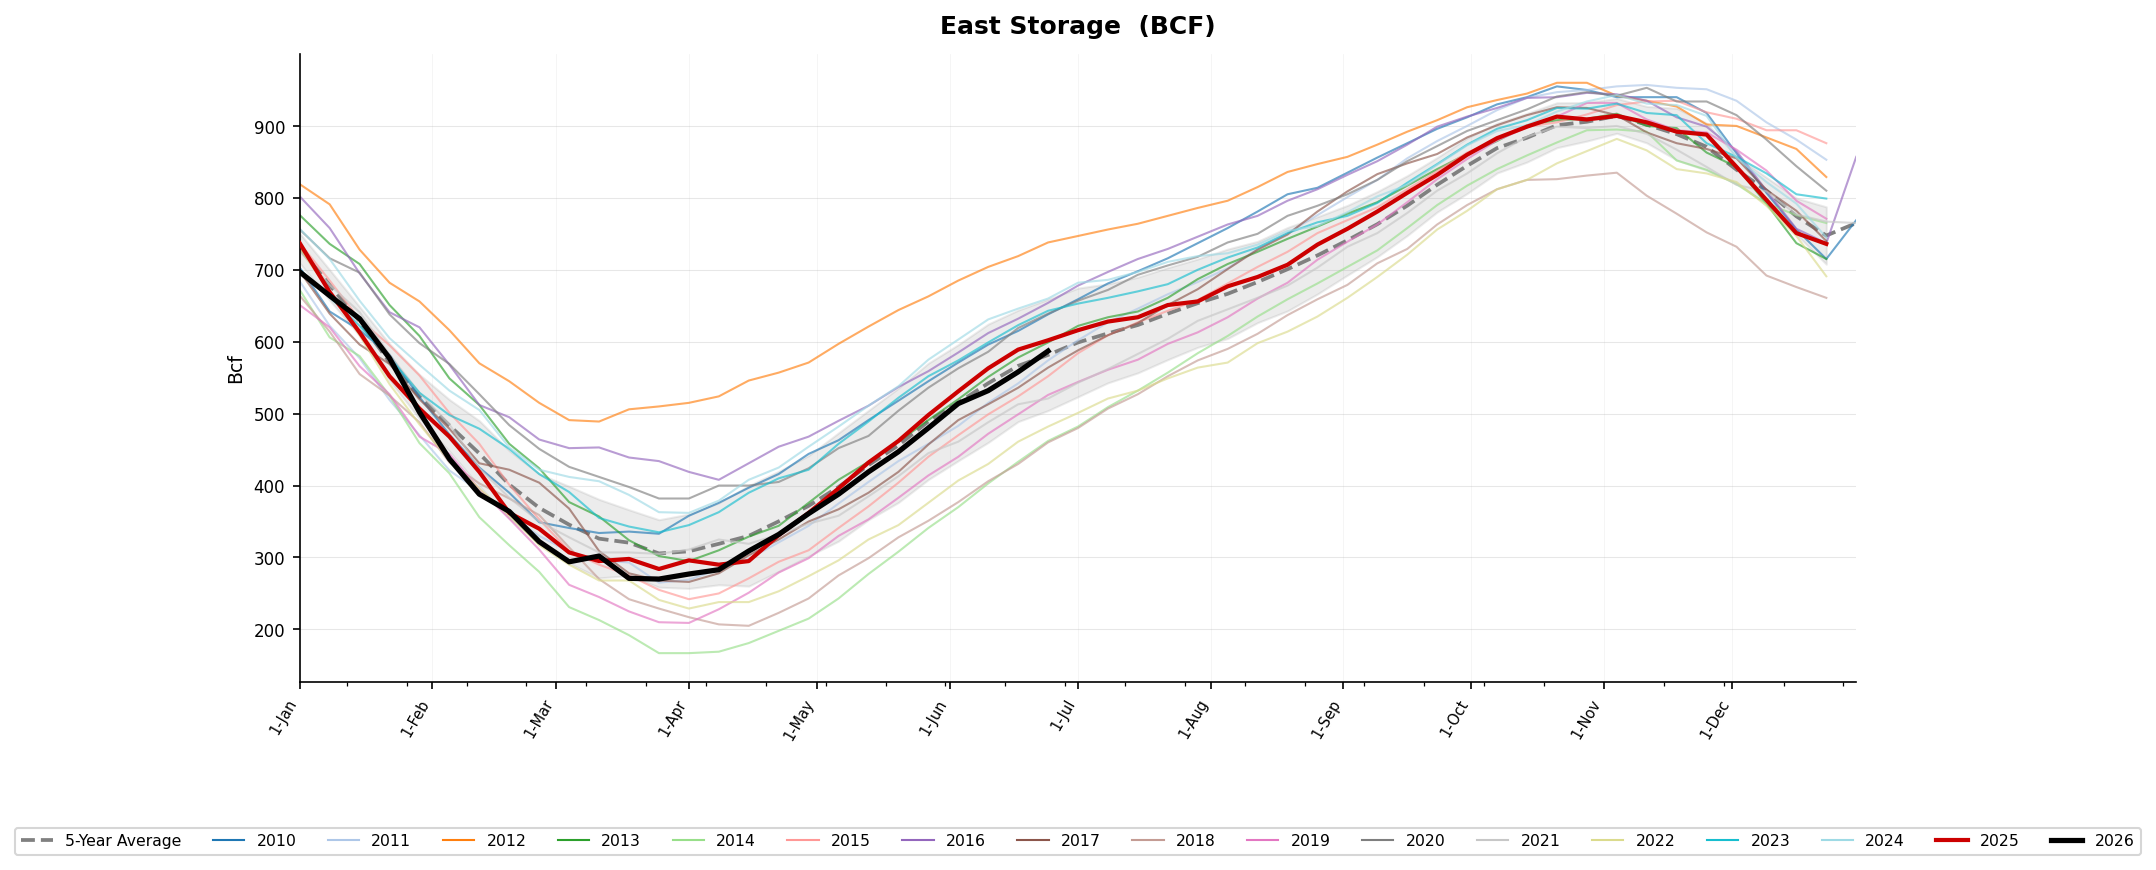

  Saved: /content/Chart1_East_seasonal_overlay.png


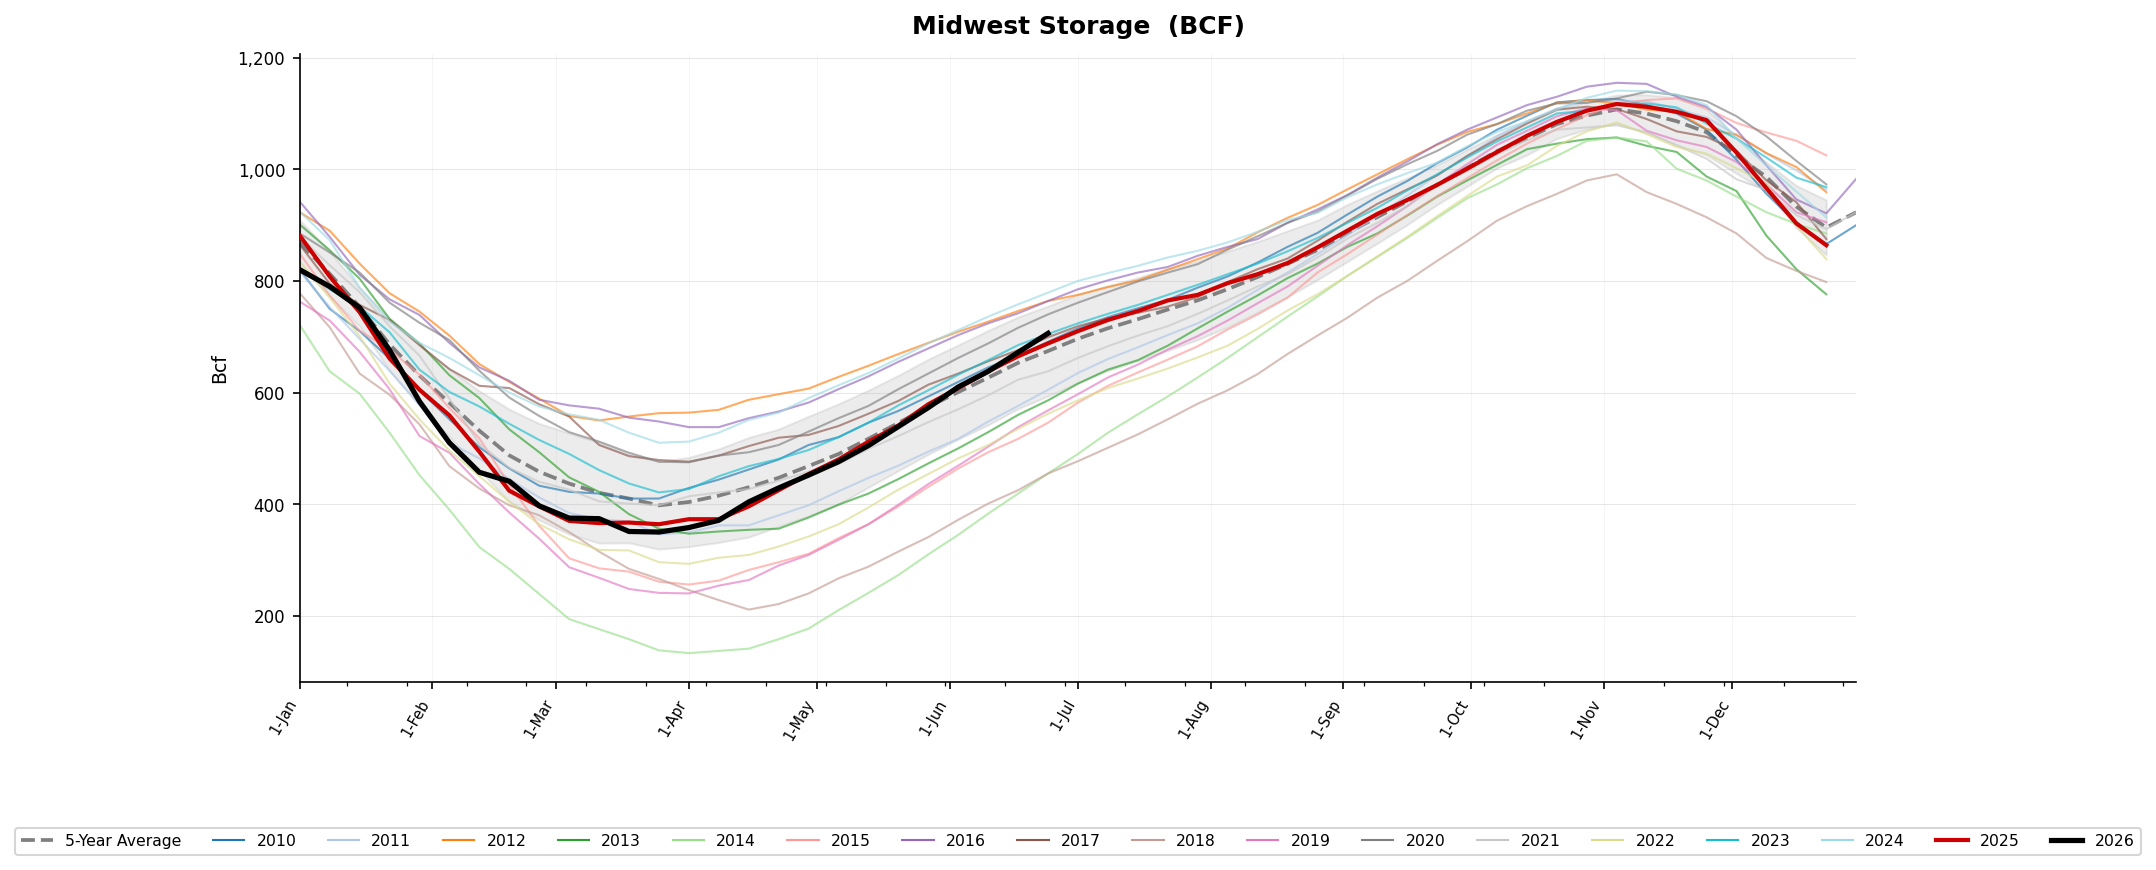

  Saved: /content/Chart1_Midwest_seasonal_overlay.png


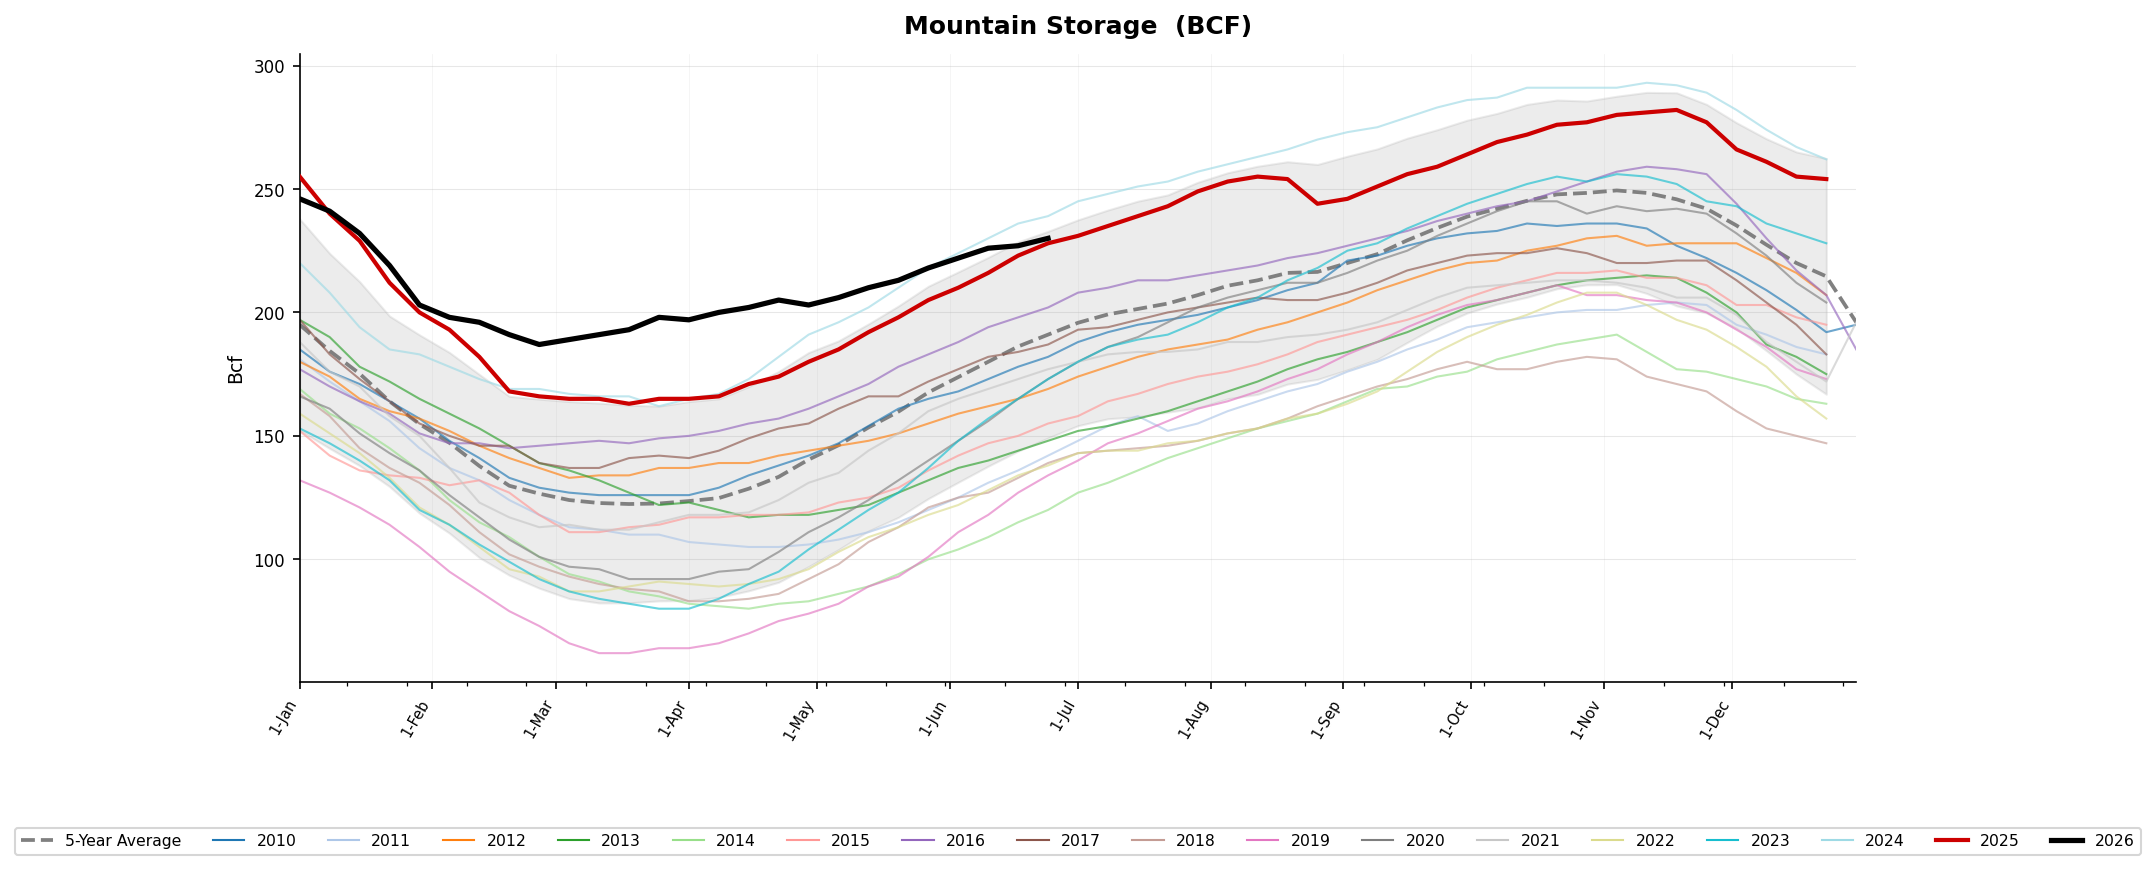

  Saved: /content/Chart1_Mountain_seasonal_overlay.png


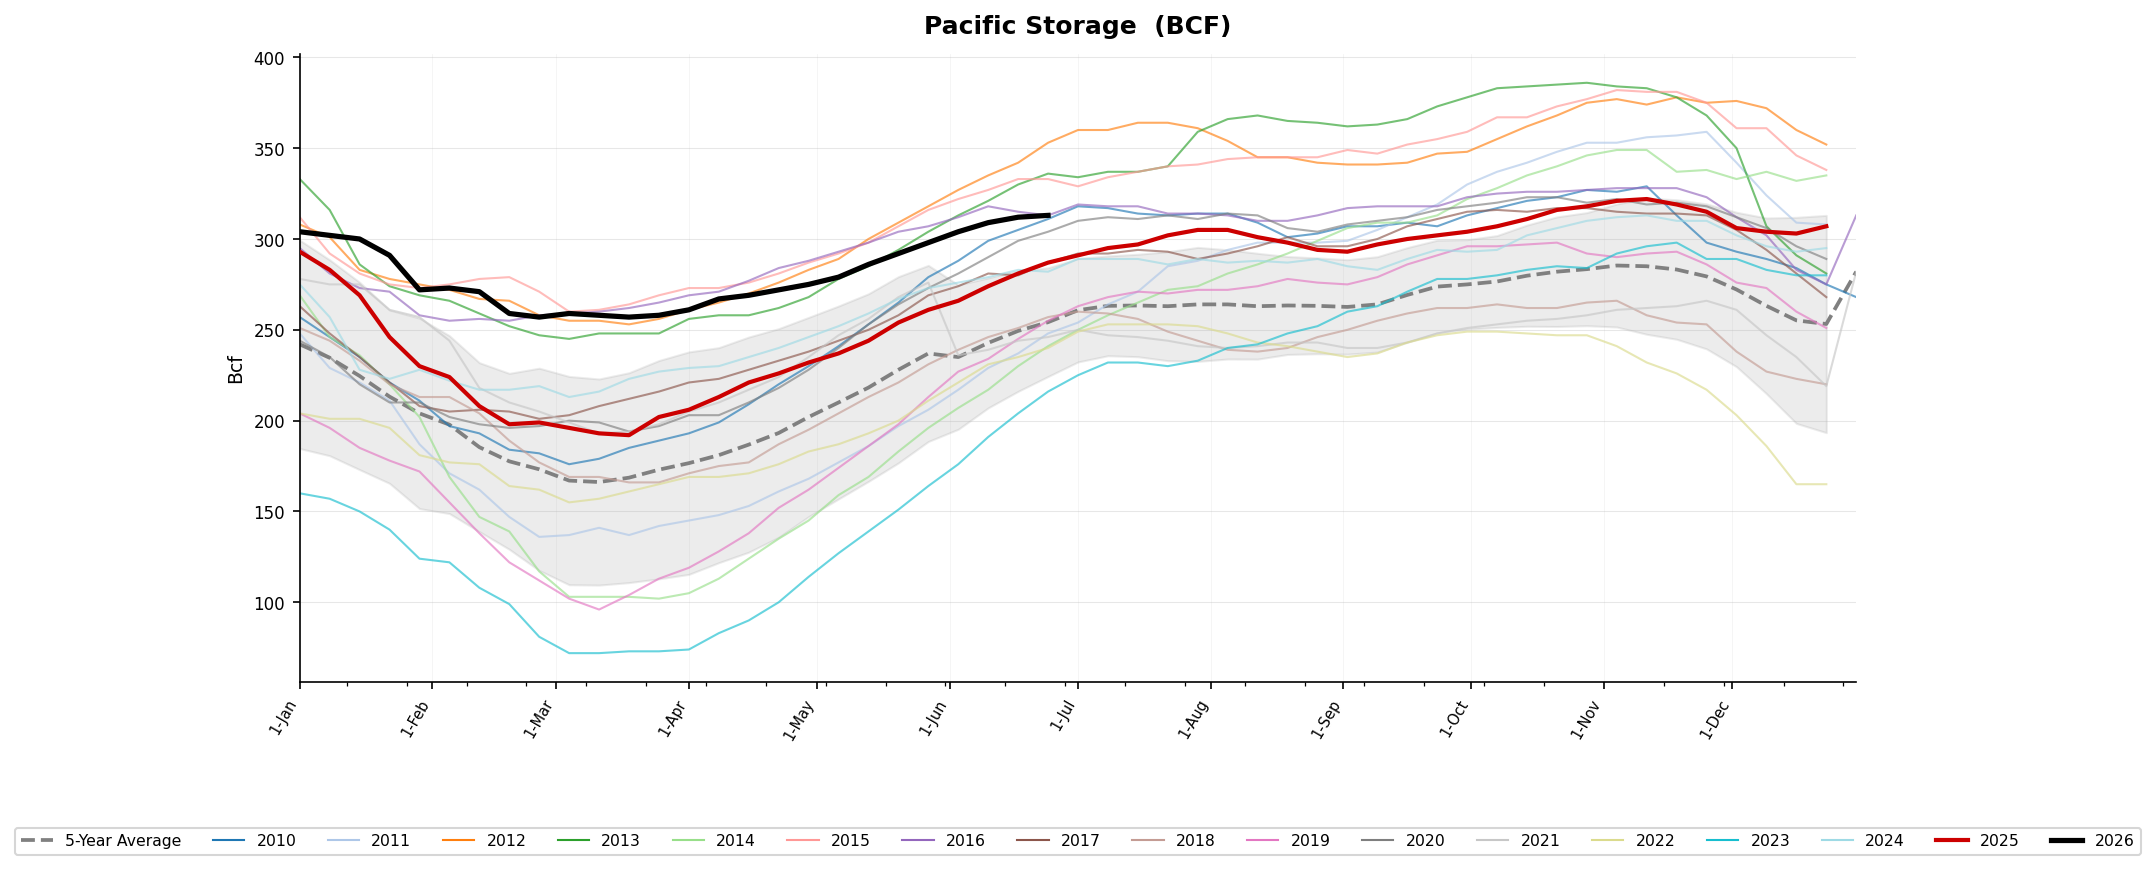

  Saved: /content/Chart1_Pacific_seasonal_overlay.png


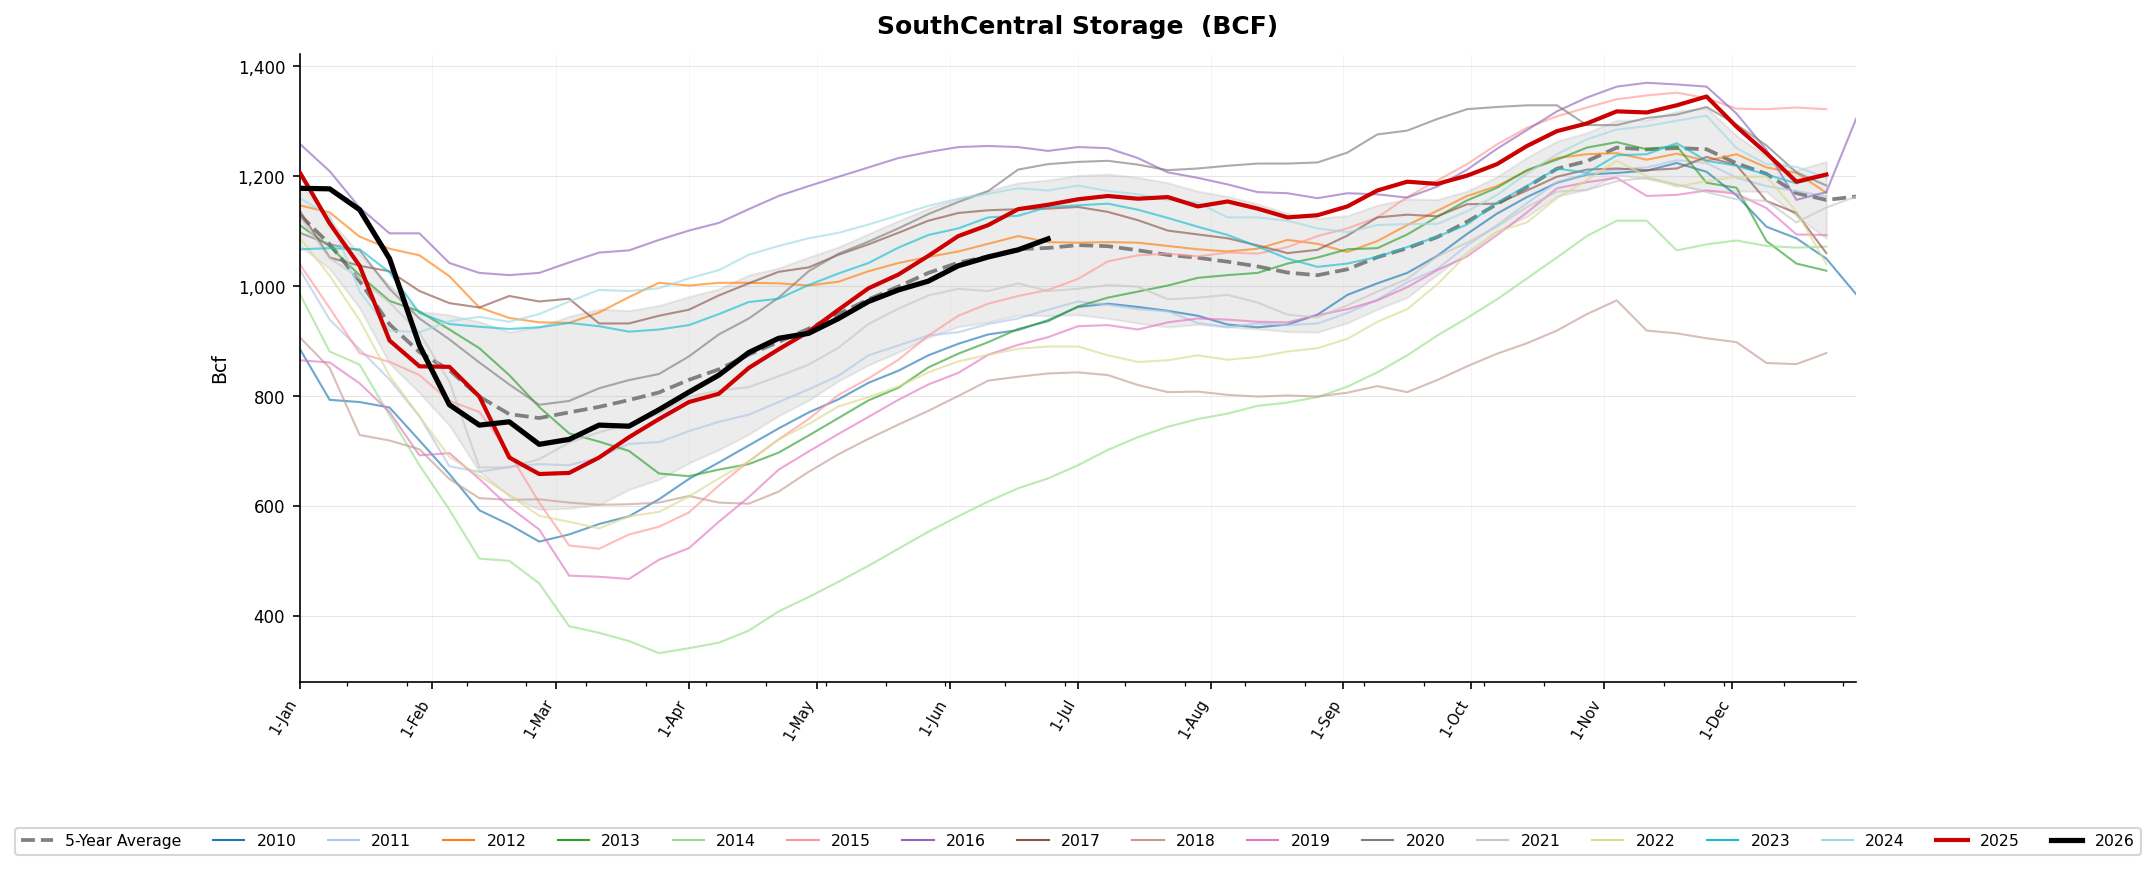

  Saved: /content/Chart1_SouthCentral_seasonal_overlay.png


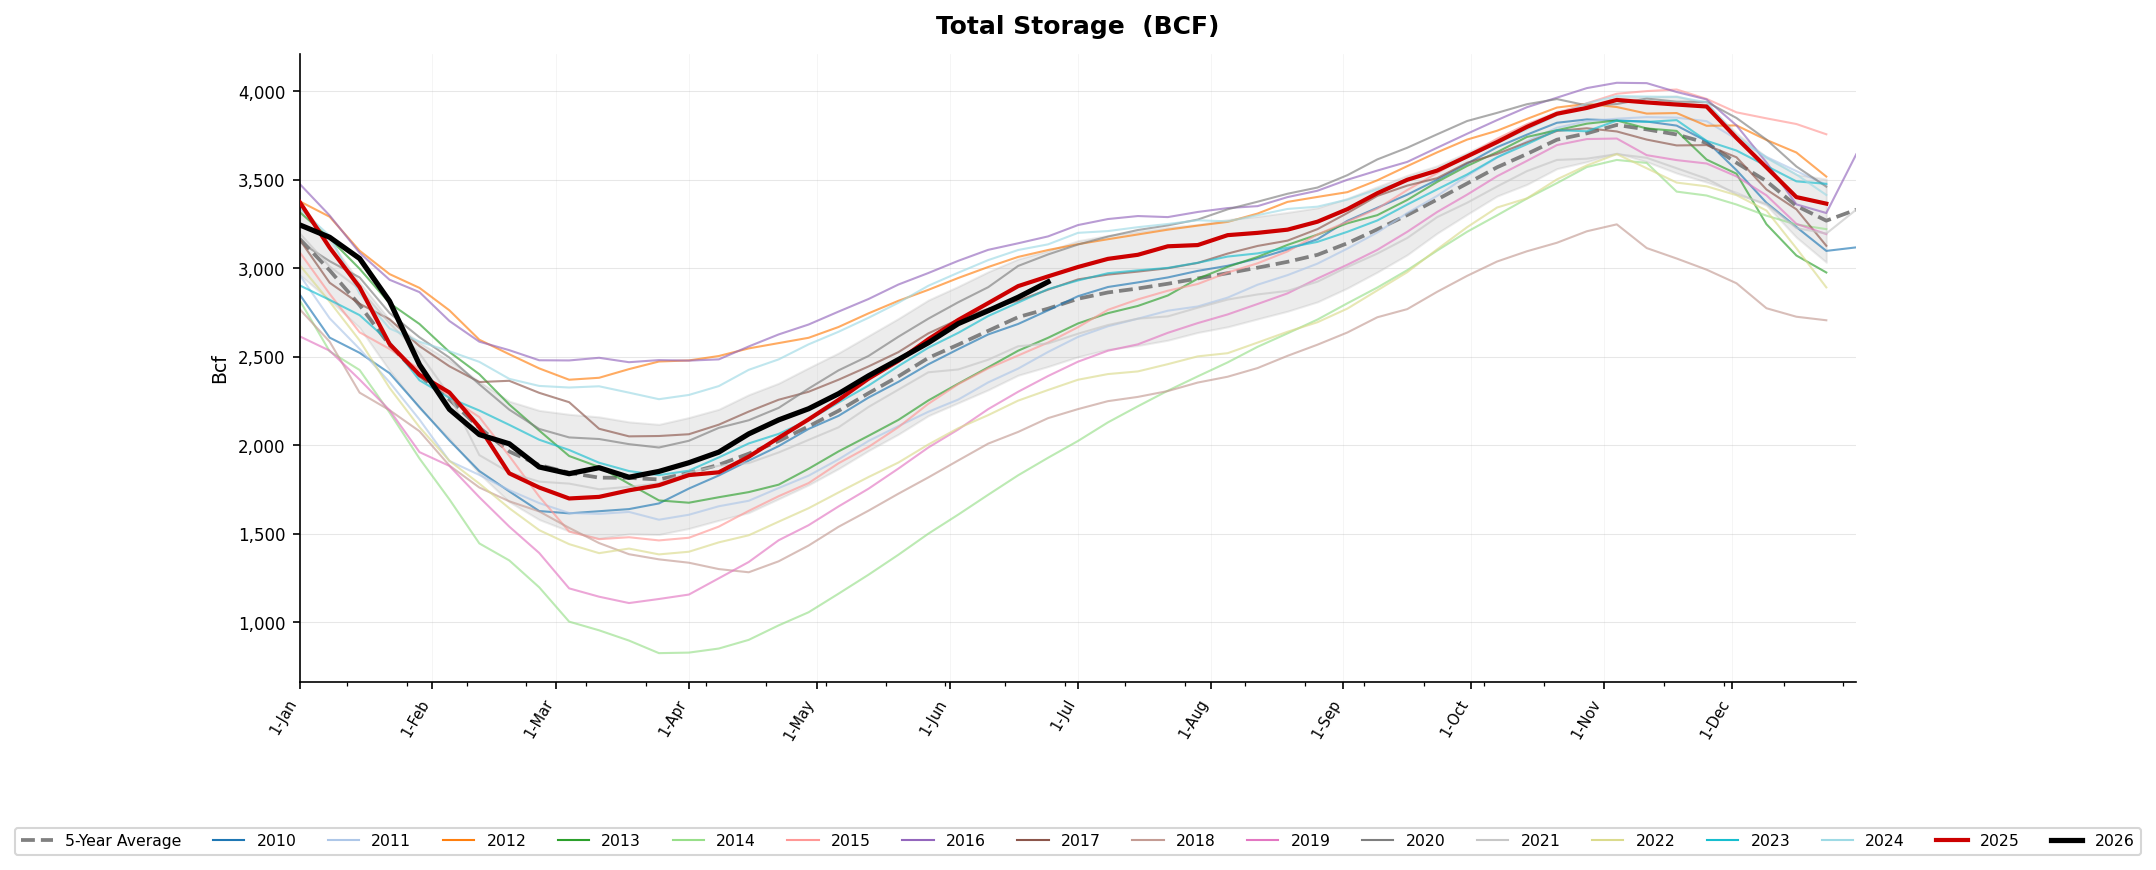

  Saved: /content/Chart1_Total_seasonal_overlay.png

── Chart 1b: Combined 6-Region Overlay ──


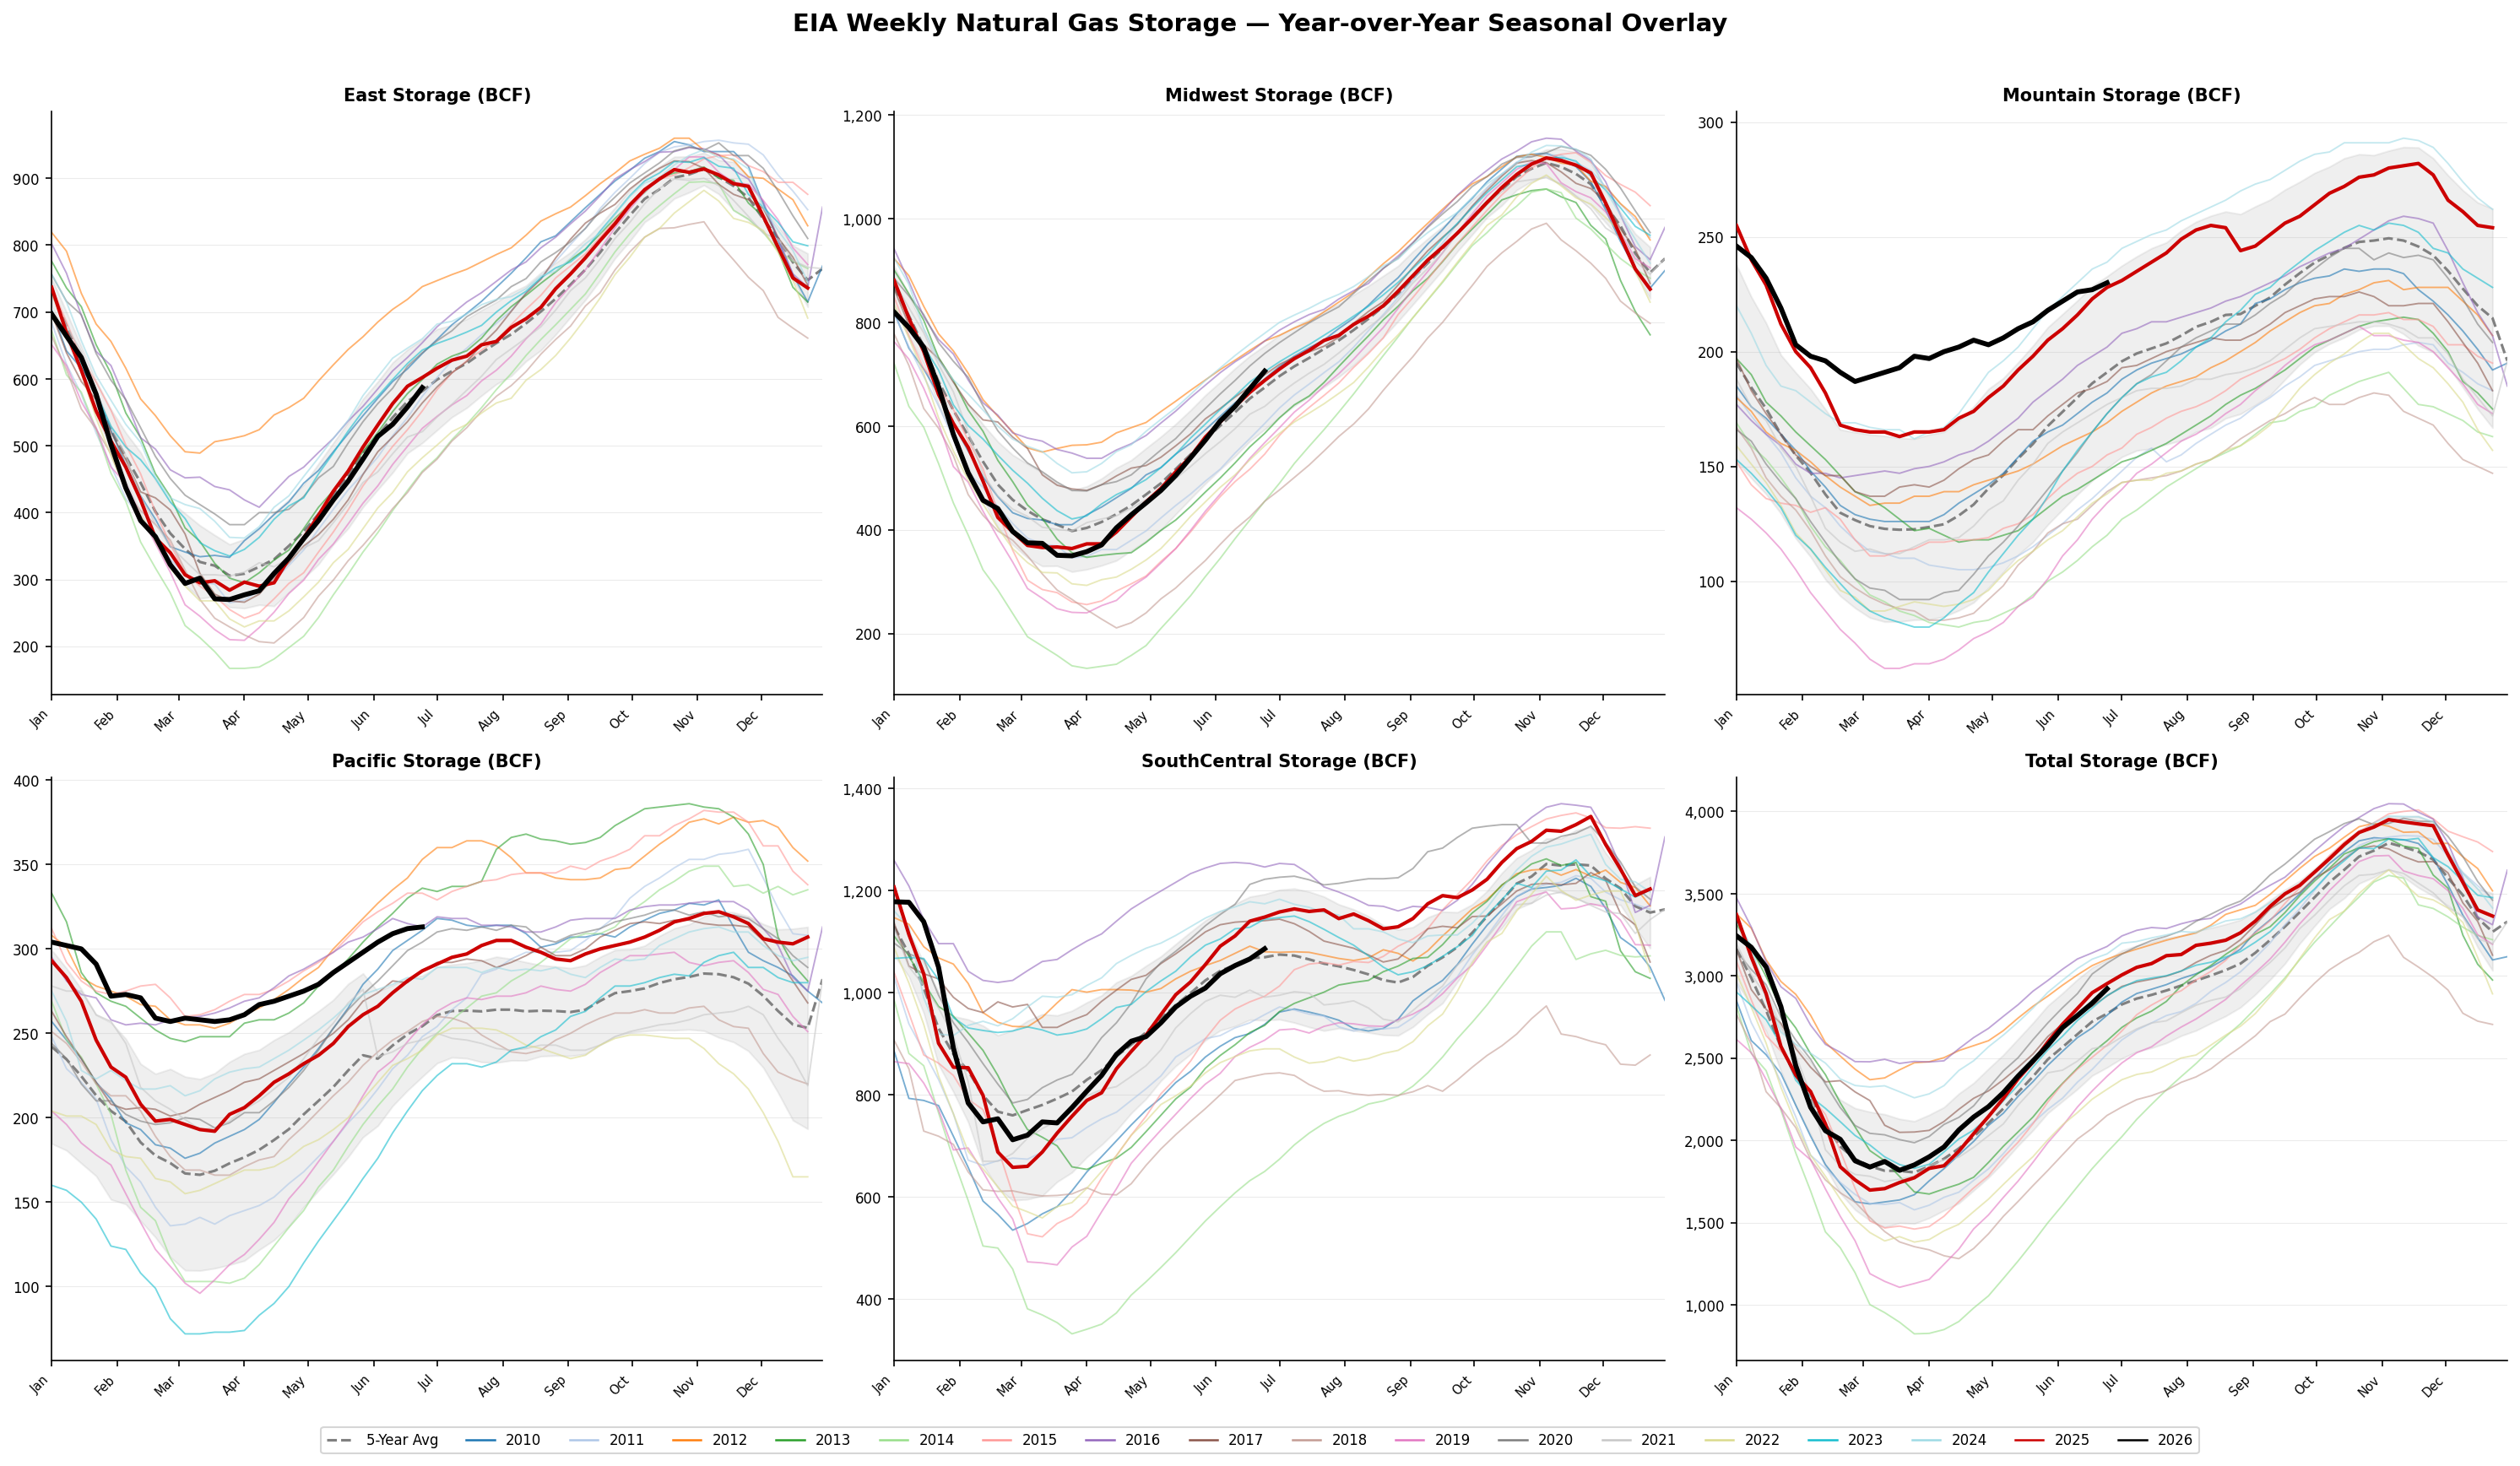

  Saved: /content/Chart1_all_regions_combined.png

── Fitting Forecast Models ──

  East (n=861)
    SARIMA         AIC=5733.6 ✓
    Fourier-ARIMAX AIC=6408.2 ✓
    Holt-Winters   FAILED: ExponentialSmoothing.fit() got an unexpected keyword argument 'minimizer_kwargs'
    Degree-Day OLS R²=0.9978 ✓
    Ensemble       (3 models)

  Midwest (n=861)
    SARIMA         AIC=5747.4 ✓
    Fourier-ARIMAX AIC=6396.4 ✓
    Holt-Winters   FAILED: ExponentialSmoothing.fit() got an unexpected keyword argument 'minimizer_kwargs'
    Degree-Day OLS R²=0.9982 ✓
    Ensemble       (3 models)

  Mountain (n=861)
    SARIMA         AIC=3529.9 ✓
    Fourier-ARIMAX AIC=3882.7 ✓
    Holt-Winters   FAILED: ExponentialSmoothing.fit() got an unexpected keyword argument 'minimizer_kwargs'
    Degree-Day OLS R²=0.9975 ✓
    Ensemble       (3 models)

  Pacific (n=861)
    SARIMA         AIC=4644.2 ✓
    Fourier-ARIMAX AIC=5143.6 ✓
    Holt-Winters   FAILED: ExponentialSmoothing.fit() got an unexpected keyword ar

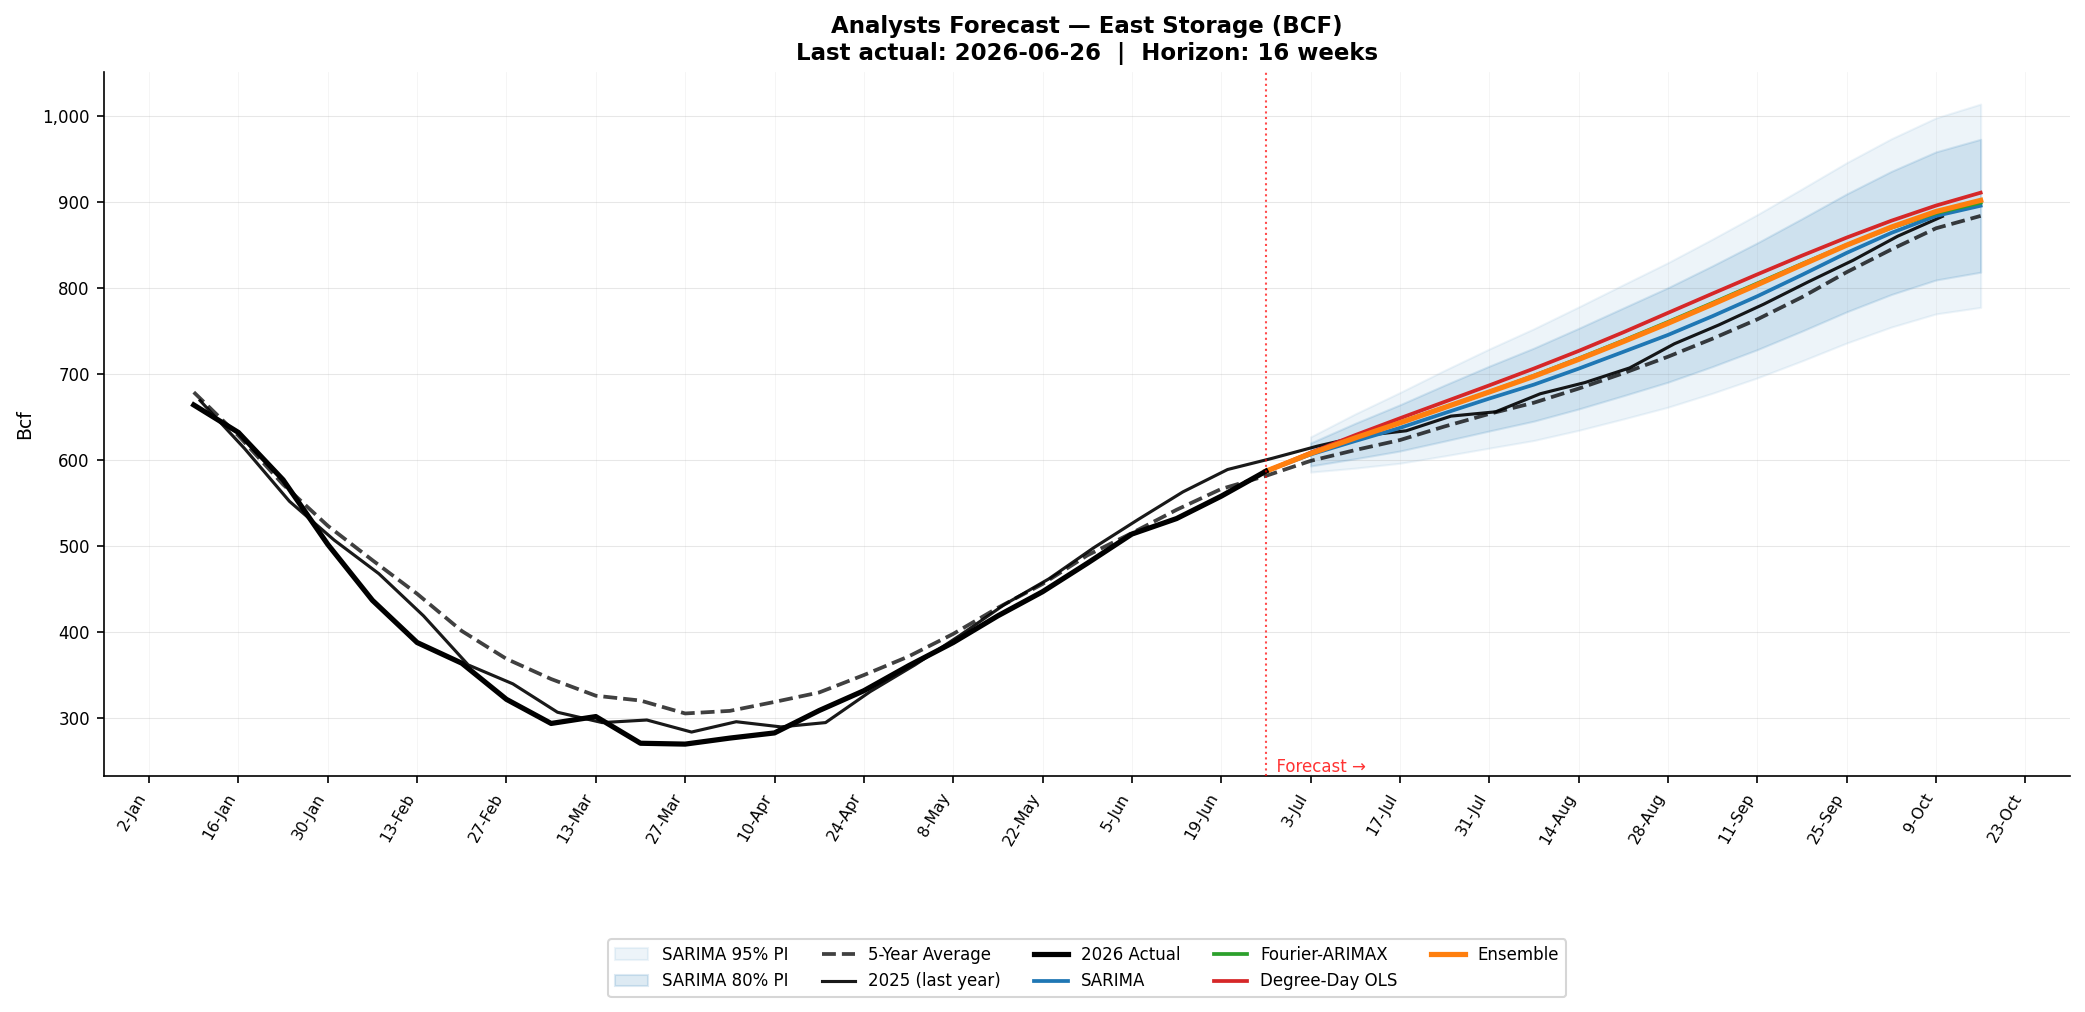

  Saved: /content/Chart2_East_forecast_fan.png


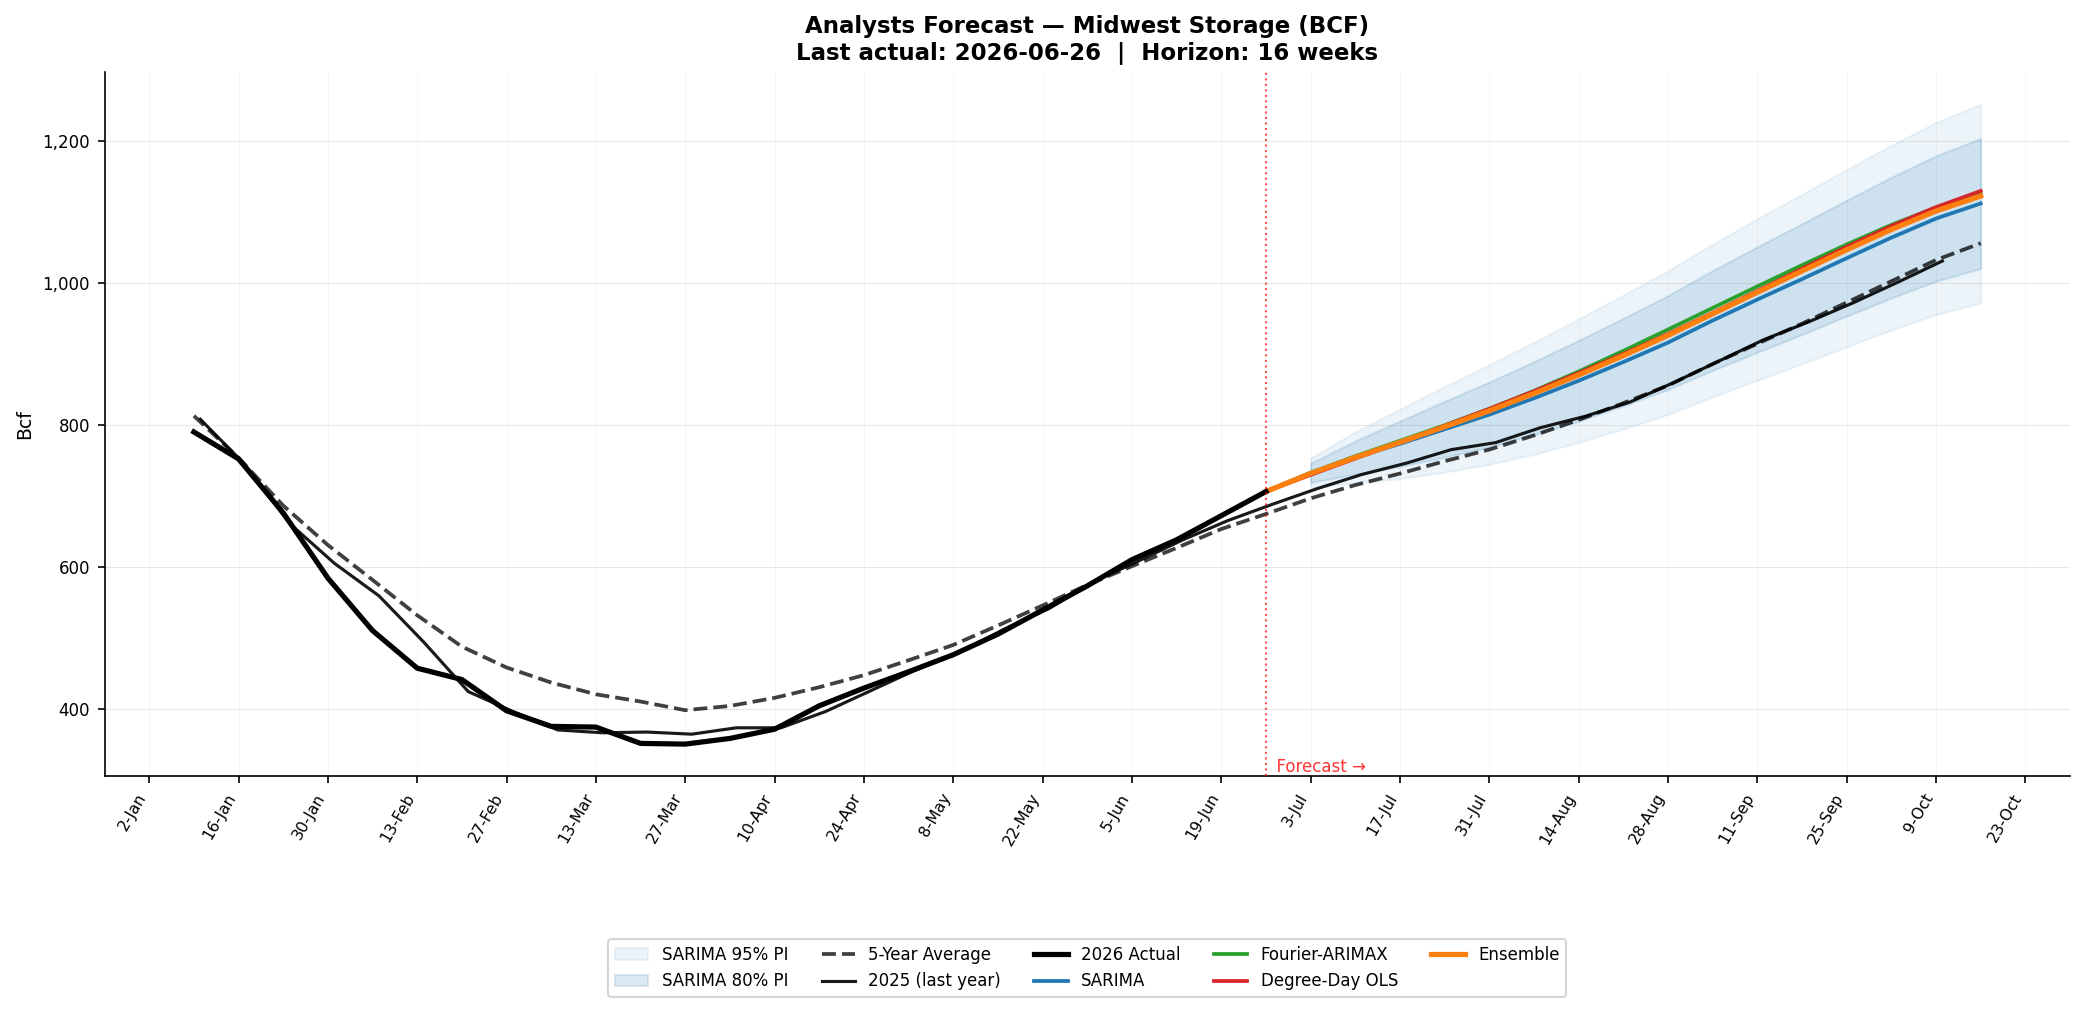

  Saved: /content/Chart2_Midwest_forecast_fan.png


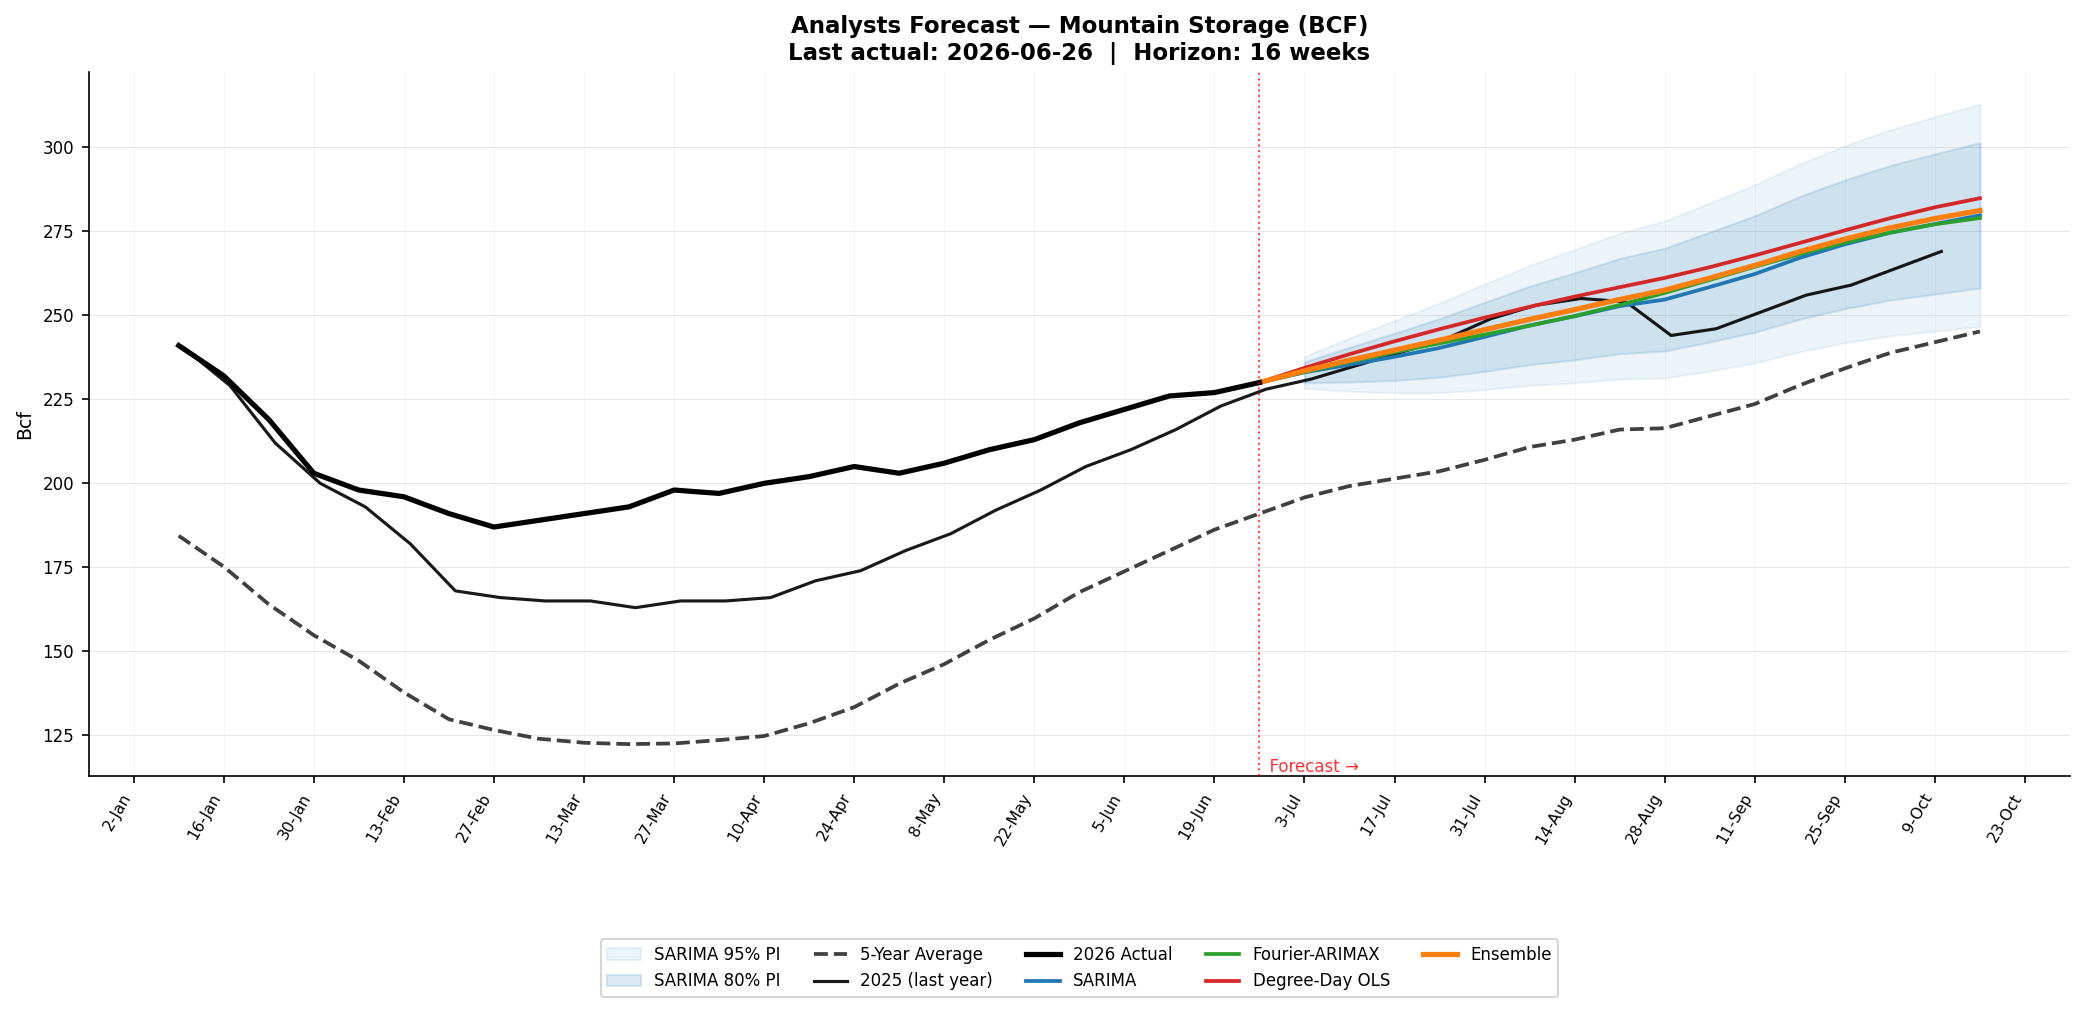

  Saved: /content/Chart2_Mountain_forecast_fan.png


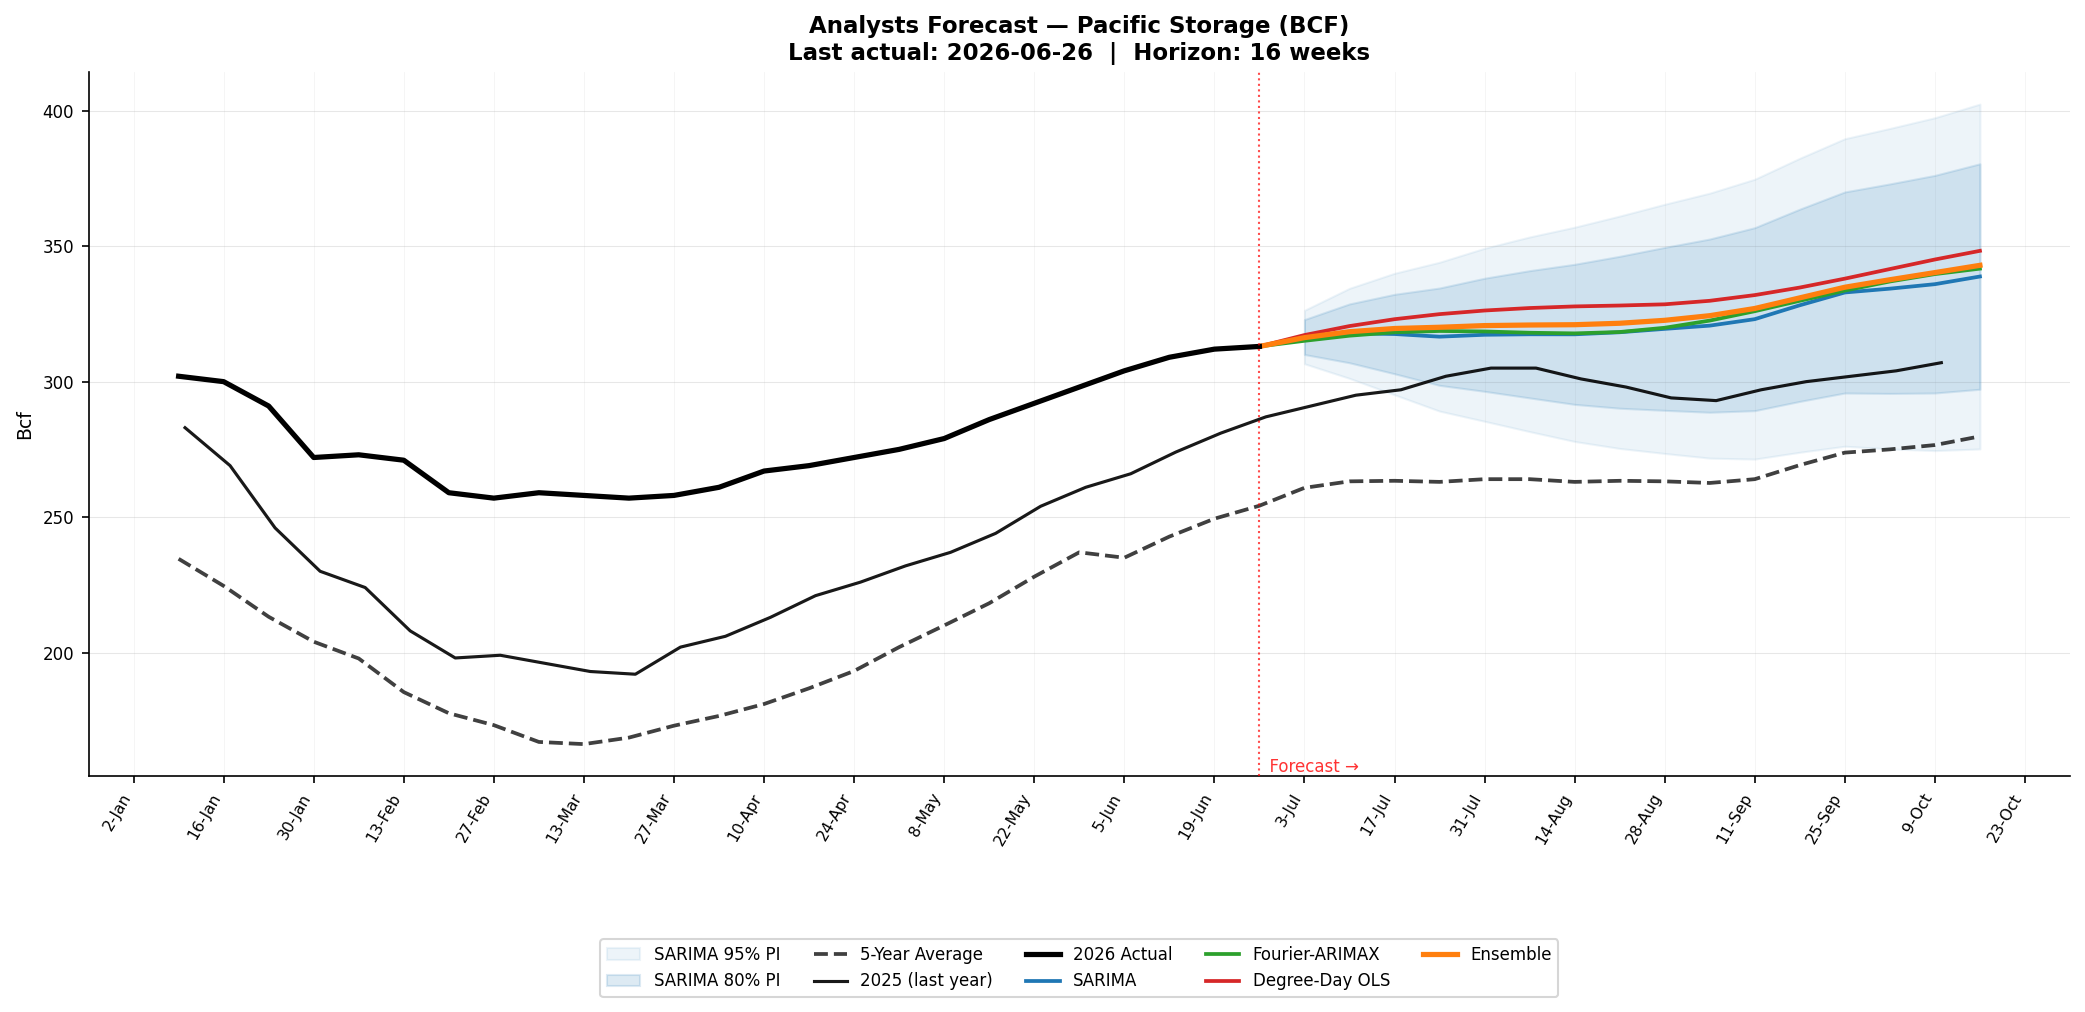

  Saved: /content/Chart2_Pacific_forecast_fan.png


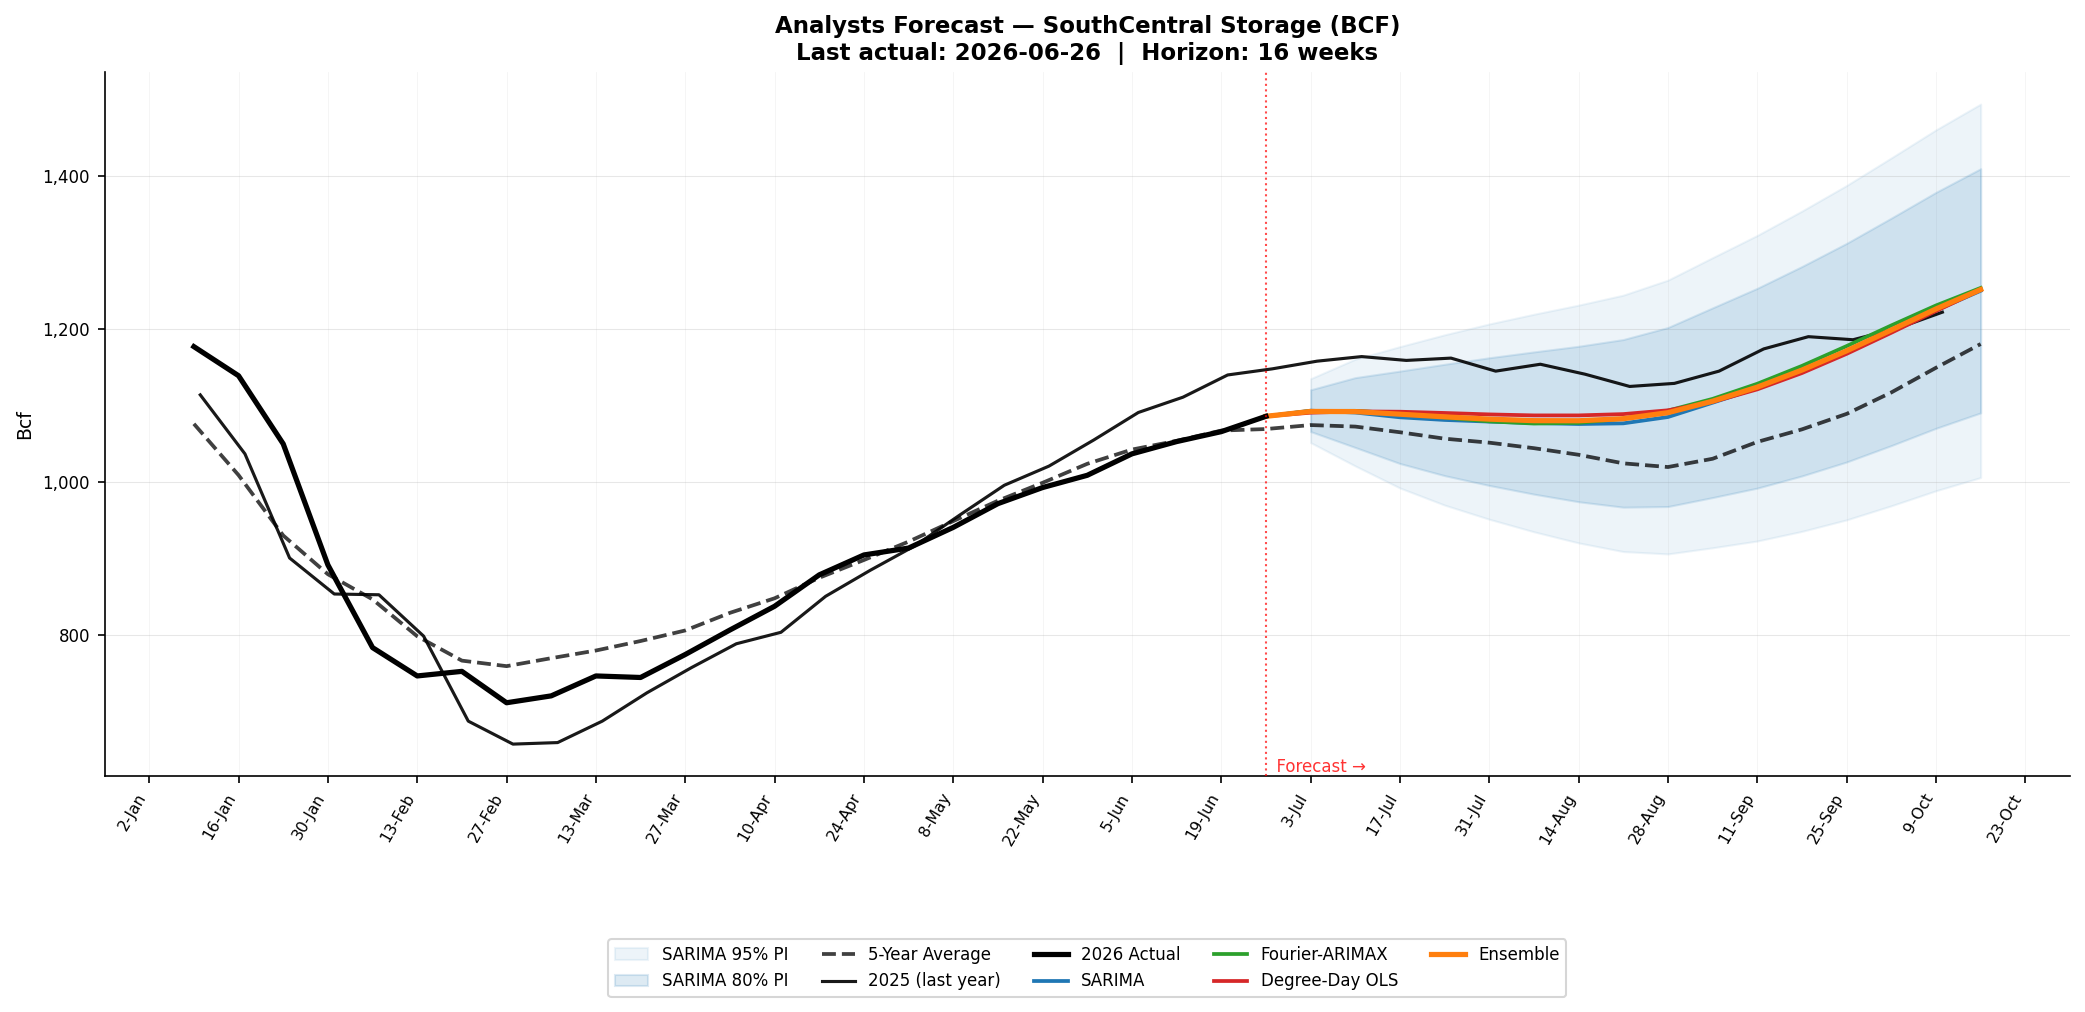

  Saved: /content/Chart2_SouthCentral_forecast_fan.png


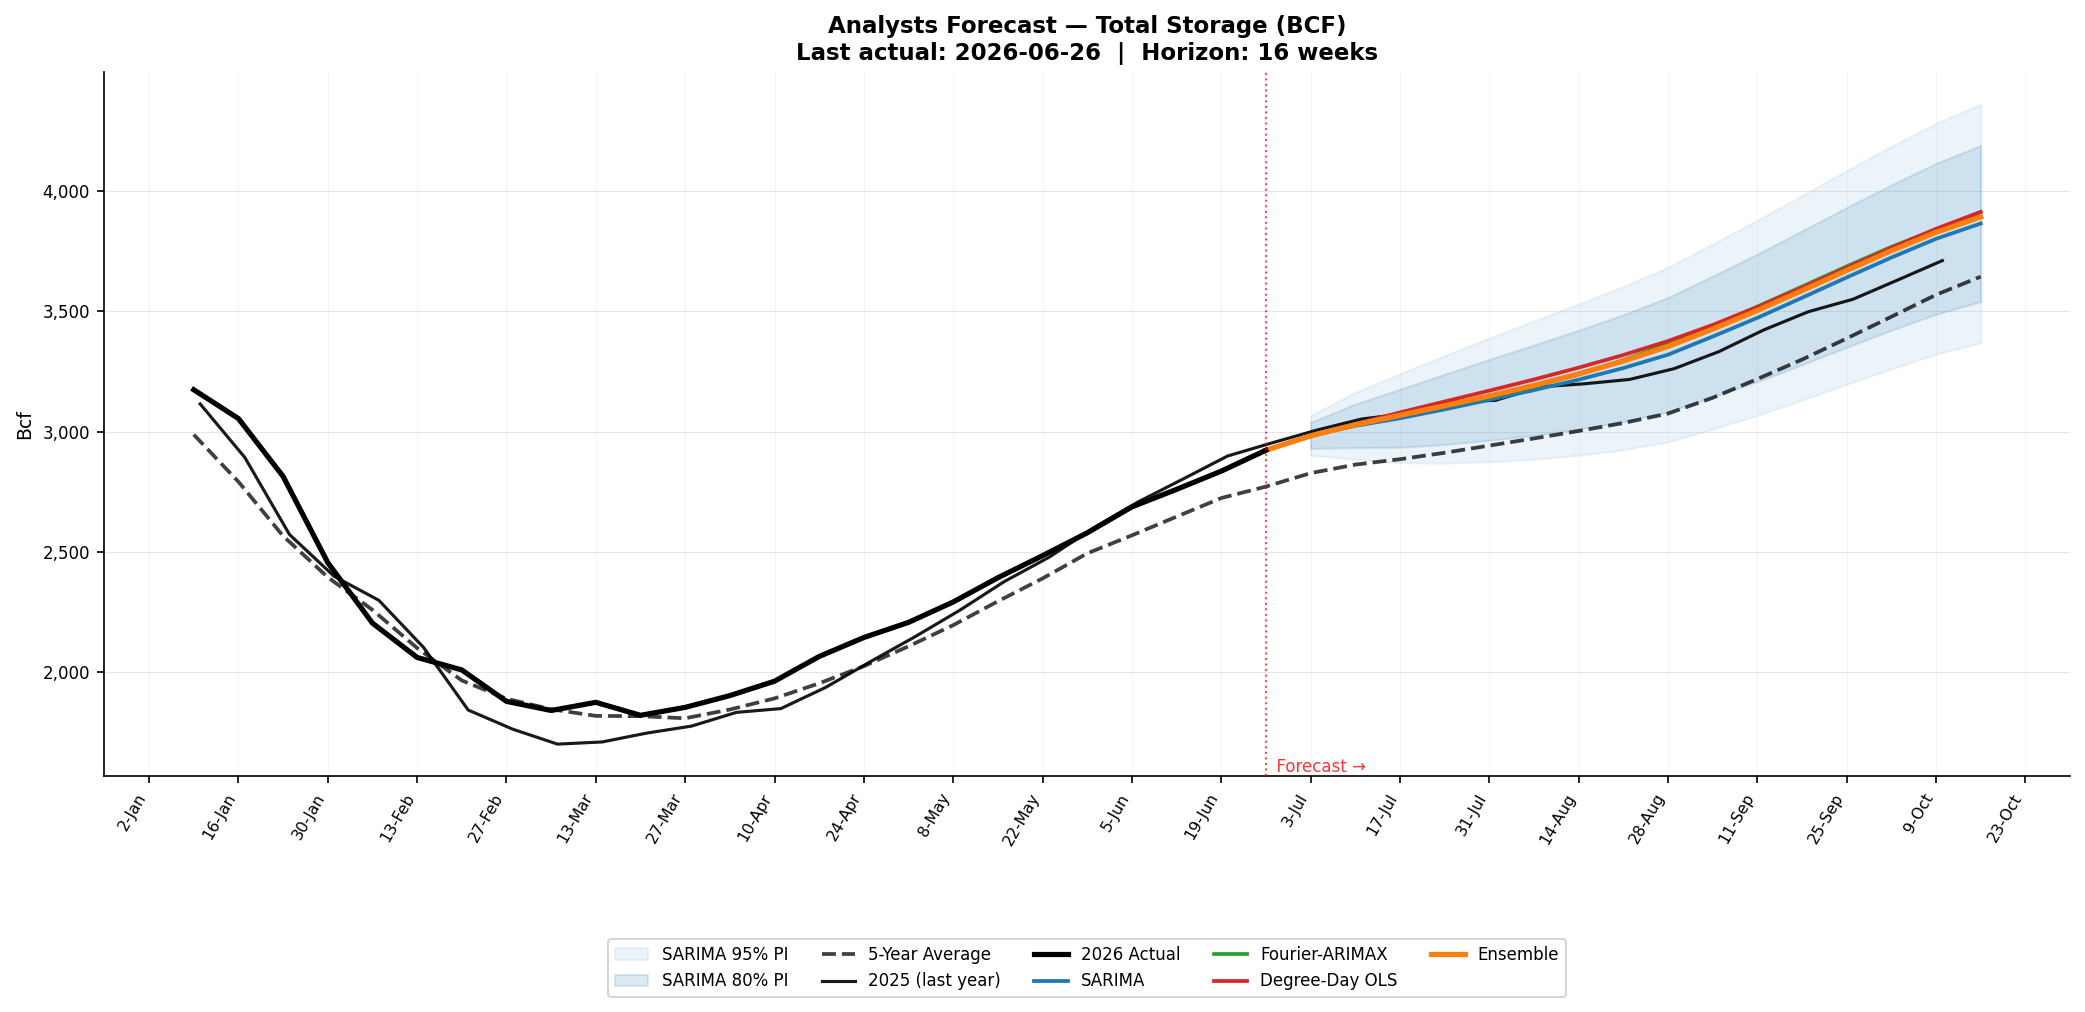

  Saved: /content/Chart2_Total_forecast_fan.png

── Chart 2b: Total Storage — Full Analyst-Style (reference match) ──


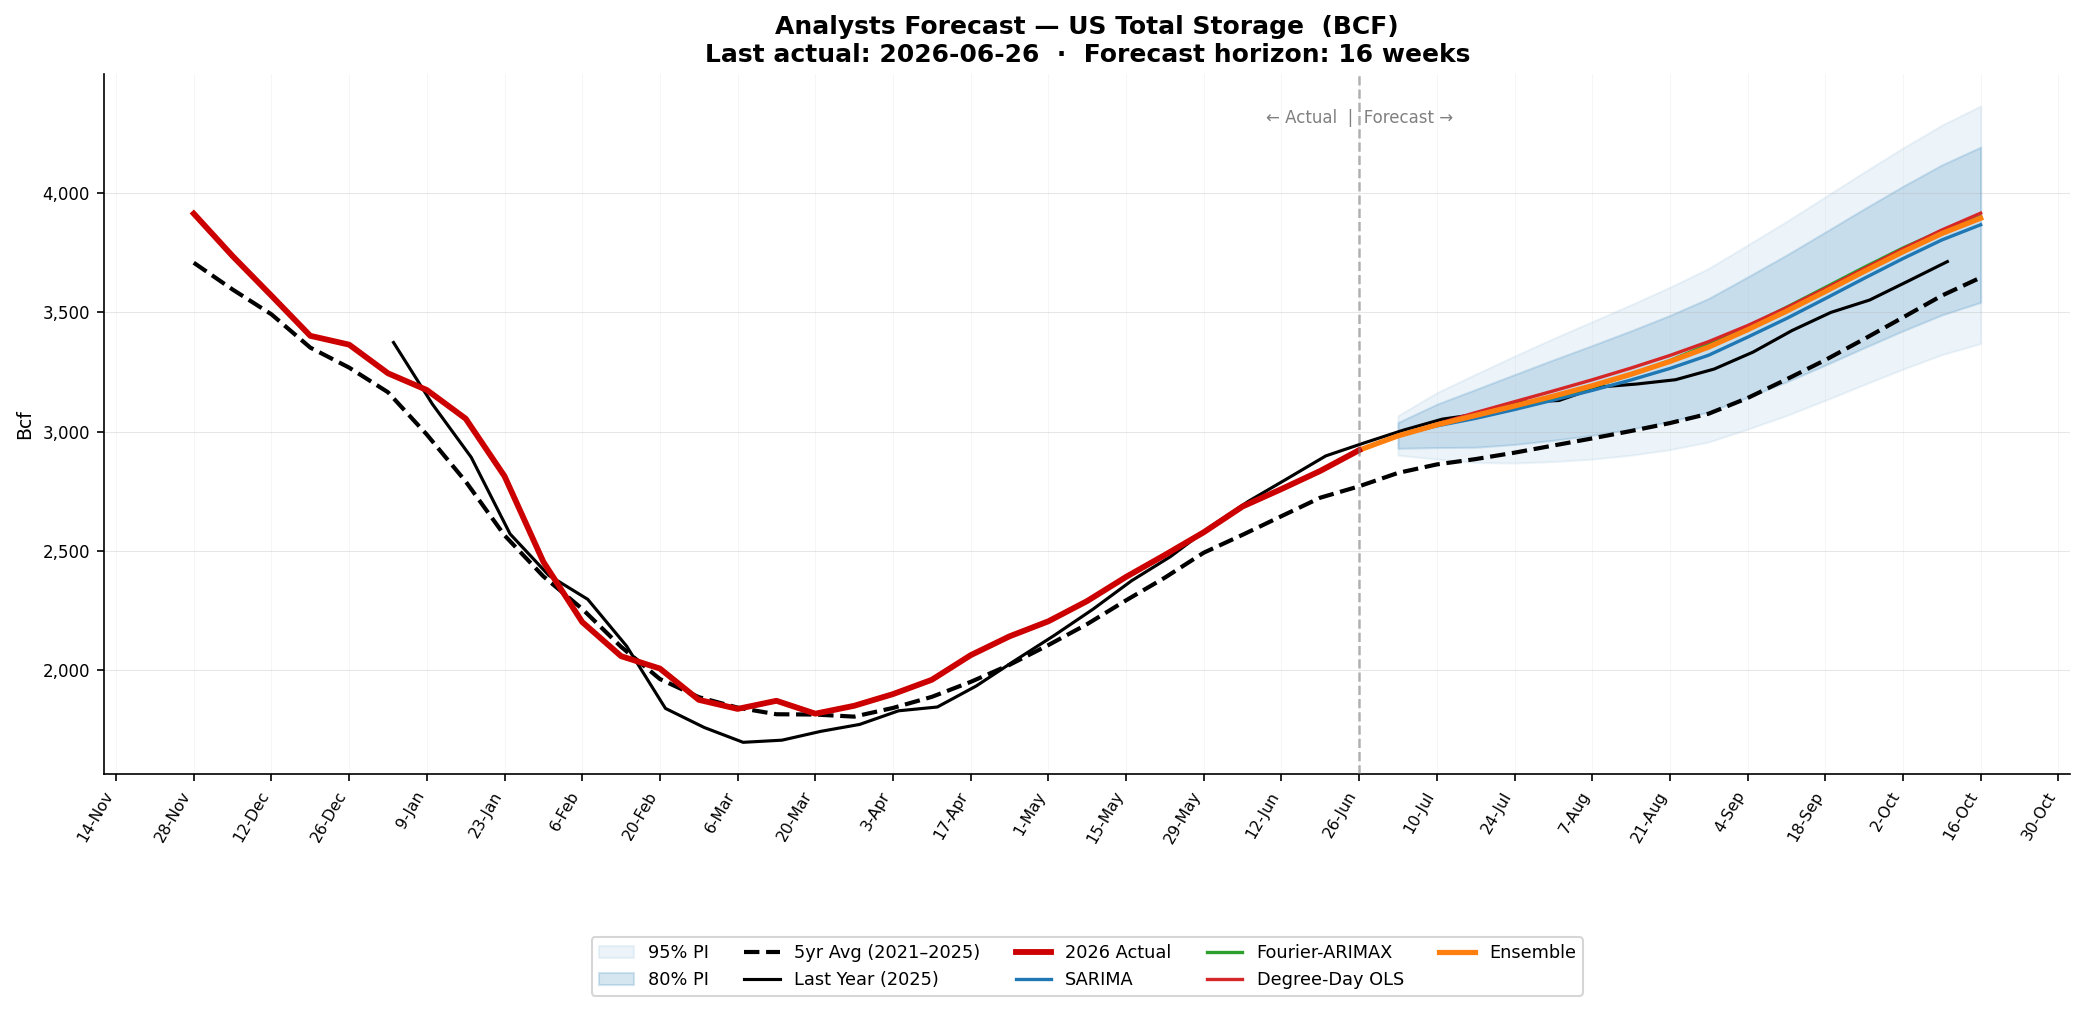

  Saved: /content/Chart2_Total_analyst_style.png

── Chart 3: Surplus/Deficit Heat Gauge ──


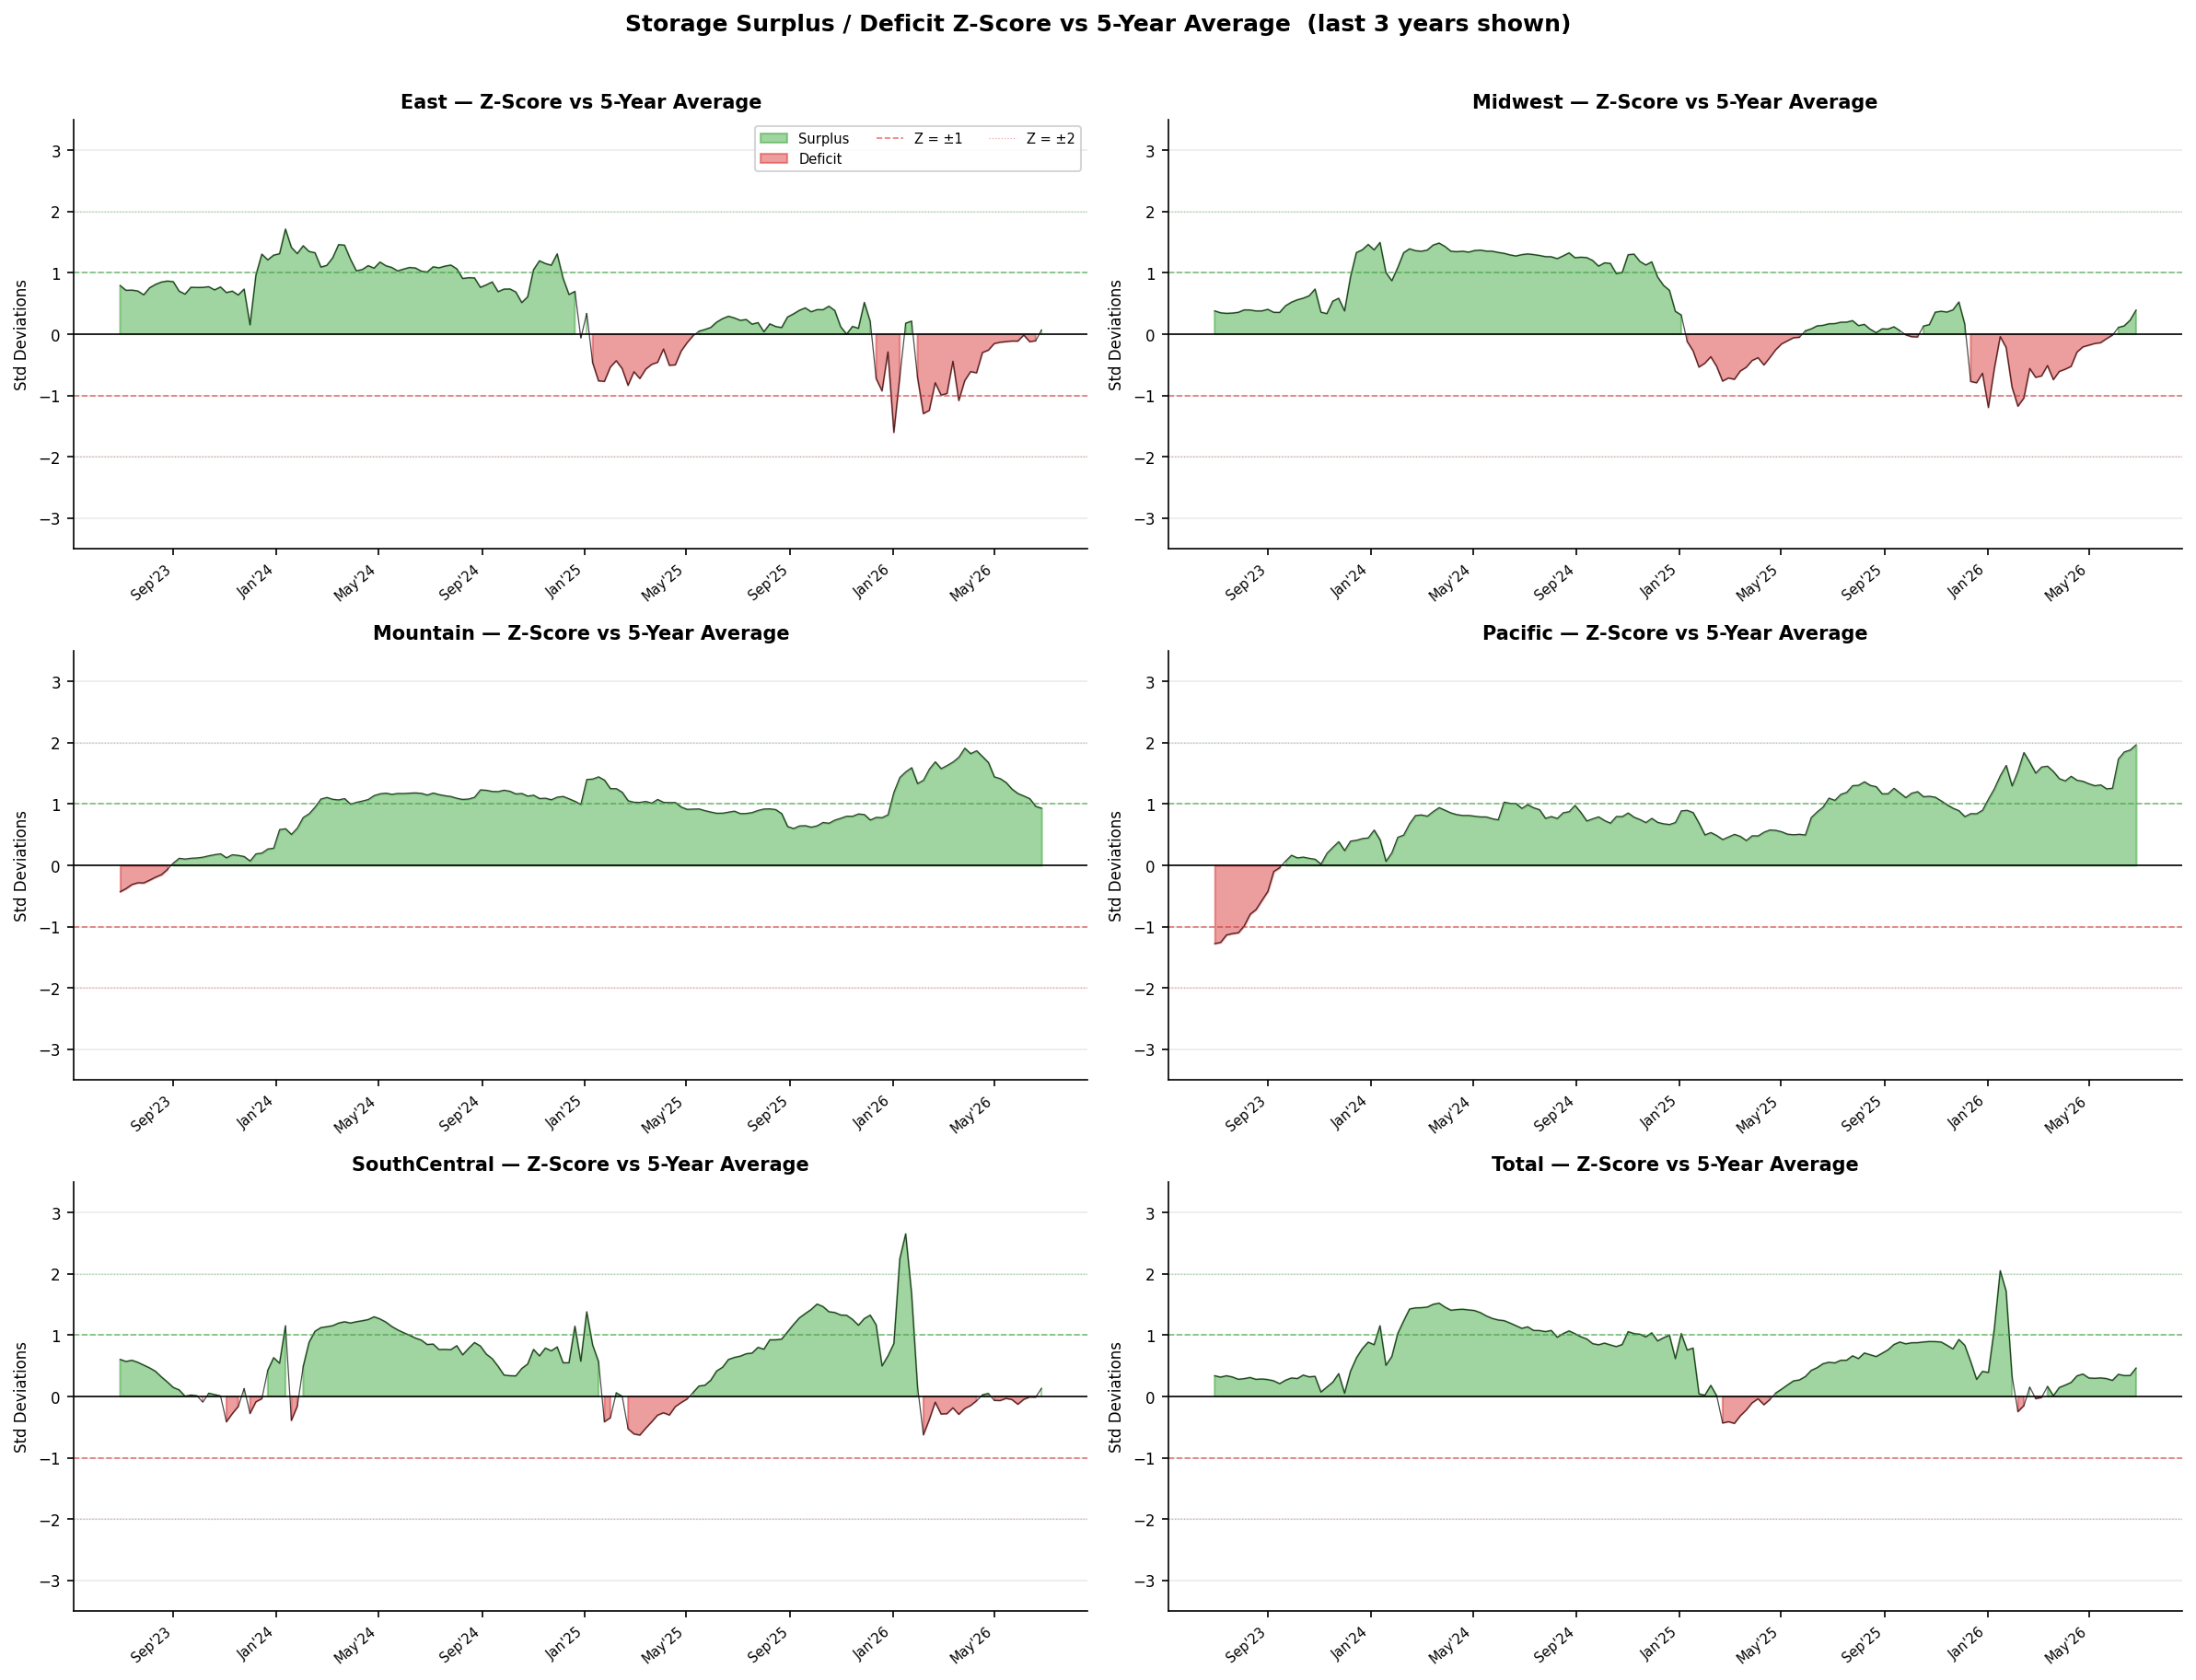

  Saved: /content/Chart3_surplus_deficit_zscore.png

── Forecast Summary Table — Total Storage ──
      Week  WoY  5yr_Avg  SARIMA  Fourier-ARIMAX Holt-Winters  Degree-Day OLS  Ensemble  vs_5yr
2026-07-03   27   2827.0  2984.0          2982.0         None          2980.0    2982.0   155.0
2026-07-10   28   2862.0  3024.0          3029.0         None          3032.0    3028.0   166.0
2026-07-17   29   2885.0  3055.0          3068.0         None          3079.0    3068.0   183.0
2026-07-24   30   2911.0  3092.0          3105.0         None          3125.0    3107.0   196.0
2026-07-31   31   2941.0  3132.0          3143.0         None          3170.0    3148.0   207.0
2026-08-07   32   2971.0  3172.0          3187.0         None          3217.0    3192.0   221.0
2026-08-14   33   3002.0  3216.0          3238.0         None          3266.0    3240.0   238.0
2026-08-21   34   3035.0  3264.0          3298.0         None          3319.0    3293.0   258.0
2026-08-28   35   3075.0  3320.0      

In [6]:

# ╔══════════════════════════════════════════════════════════════════════════════
# FORECAST TABLE
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n── Forecast Summary Table — Total Storage ──")

reg  = "Total"
mf   = model_forecasts.get(reg, {})
last = stor[["Week","WeekOfYear",reg]].dropna(subset=[reg]).iloc[-1]
pivot = build_seasonal_df(stor, reg)
avg5, std5, _ = compute_5yr_avg(pivot, CURRENT_YEAR, n=5)
last_date= stor["Week"].max()

rows = []
for h in range(1, FORECAST_WEEKS+1):
    wk  = last_date + pd.Timedelta(weeks=h)
    woy = wk.isocalendar()[1]
    a5  = avg5.get(woy, np.nan)
    row = {"Week": wk.date(), "WoY": woy,
           "5yr_Avg": round(a5, 0) if not np.isnan(a5) else None}
    for m in ["SARIMA","Fourier-ARIMAX","Holt-Winters","Degree-Day OLS","Ensemble"]:
        if m in mf and h-1 < len(mf[m]):
            row[m] = round(mf[m][h-1], 0)
        else:
            row[m] = None
    if "Ensemble" in row and row["Ensemble"] and row["5yr_Avg"]:
        row["vs_5yr"] = round(row["Ensemble"] - row["5yr_Avg"], 0)
    else:
        row["vs_5yr"] = None
    rows.append(row)

fcast_tbl = pd.DataFrame(rows)
print(fcast_tbl.to_string(index=False))

csv_path = os.path.join(OUT_FOLDER, "Forecast_table_Total.csv")
fcast_tbl.to_csv(csv_path, index=False)
print(f"\n  CSV saved: {csv_path}")

# ╔══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ╚══════════════════════════════════════════════════════════════════════════════

print("\n" + "═"*70)
print("  STORAGE ANALYSIS COMPLETE")
print("═"*70)
print(f"\n  Data: {len(stor):,} weekly obs  "
      f"({stor['Week'].min().date()} → {stor['Week'].max().date()})")
print(f"  Current year: {CURRENT_YEAR}  |  "
      f"Last actual: {stor['Week'].max().date()}")
print(f"  Forecast horizon: {FORECAST_WEEKS} weeks")
print(f"\n📊 Charts saved to {OUT_FOLDER}:")
print("  Chart1_<region>_seasonal_overlay.png  — Year-over-year overlay (×6)")
print("  Chart1_all_regions_combined.png        — Combined 2×3 panel")
print("  Chart2_<region>_forecast_fan.png       — Analyst forecast fan (×6)")
print("  Chart2_Total_analyst_style.png         — Total storage, reference style")
print("  Chart3_surplus_deficit_zscore.png      — Z-score heat gauge (×6)")
print("  Forecast_table_Total.csv               — Tabular forecast output")
print(f"\n📋 Key objects:")
print("  stor             — full integrated DataFrame")
print("  model_forecasts  — dict[region][model] = forecast array")
print("  COLORS           — year→colour mapping")
print("═"*70)